In [2]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import find_peaks, butter, filtfilt, detrend, windows
import matplotlib.pyplot as plt

# Material properties (Al 6061 by default)
E_GPa = 69.0      # GPa (Young's modulus)
rho = 2700.0      # kg/m^3 (density)

# Section geometry (bending about h)
b_mm = 11.4       # mm (width b)
h_mm = 0.70       # mm (height h)

# Processing
FREQ_MIN_HZ = 0.5
HIGHPASS_CUTOFF_HZ = 20
HIGHPASS_ORDER = 1

# ---- Theoretical: cantilever with rectangular cross-section ----
# Roots of cosh(βL) cos(βL) = -1 for an ideal cantilever:
BETA_L = {
    1: 1.875104068711961,
    2: 4.694091132974174,
    3: 7.854757438237612,
    4: 10.995540734875466
}

In [3]:
# Folder roots by length
ROOT_1_5 = r"C:\\Users\\axelr\\OneDrive\\Escritorio\\Multitask Learning for Damage Detection and Localization in Beams Using Fiber-Optic Sensors\\notebooks\\analysis-codes\\healthy_beam_lectures\\healthy_beam_5cm"
ROOT_1_6 = r"C:\\Users\\axelr\\OneDrive\\Escritorio\\Multitask Learning for Damage Detection and Localization in Beams Using Fiber-Optic Sensors\\notebooks\\analysis-codes\\healthy_beam_lectures\\healthy_beam_6cm"
ROOT_1_7 = r"C:\\Users\\axelr\\OneDrive\\Escritorio\\Multitask Learning for Damage Detection and Localization in Beams Using Fiber-Optic Sensors\\notebooks\\analysis-codes\\healthy_beam_lectures\\healthy_beam_7cm"
ROOT_1_8 = r"C:\\Users\\axelr\\OneDrive\\Escritorio\\Multitask Learning for Damage Detection and Localization in Beams Using Fiber-Optic Sensors\\notebooks\\analysis-codes\\healthy_beam_lectures\\healthy_beam_8cm"
ROOT_1_9 = r"C:\\Users\\axelr\\OneDrive\\Escritorio\\Multitask Learning for Damage Detection and Localization in Beams Using Fiber-Optic Sensors\\notebooks\\analysis-codes\\healthy_beam_lectures\\healthy_beam_9cm"
ROOT_1_10 = r"C:\\Users\\axelr\\OneDrive\\Escritorio\\Multitask Learning for Damage Detection and Localization in Beams Using Fiber-Optic Sensors\\notebooks\\analysis-codes\\healthy_beam_lectures\\healthy_beam_10cm"

# Length map -> (root, final_inclusive_index, perturbations_per_file)
LENGTH_CONFIG = {
    0.05: (ROOT_1_5, 25, 2),   # 25 folders (0000..0024), 2 perturbations = 50
    0.06: (ROOT_1_6, 25, 2),
    0.07: (ROOT_1_7, 25, 2),
    0.08: (ROOT_1_8, 25, 2),
    0.09: (ROOT_1_9, 49, 1),   # 50 folders (0000..0049), 1 perturbation
    0.10: (ROOT_1_10, 49, 1),
}

In [4]:
def read_sampling_interval_from_header(path):
    """
    Searches inside the Tektronix CSV file for the sampling interval
    (Sample Interval) given in the first lines of the file header.
    Returns the value in seconds, or None if it is not found.
    """
    try:
        with open(path, 'r', encoding='utf-8', errors='ignore') as f:
            for _ in range(80):
                line = f.readline()
                if not line:
                    break
                if "Sample Interval" in line:
                    m = re.search(r'([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)', line)
                    if m:
                        return float(m.group(1))
    except Exception:
        pass
    return None

def load_tektronix_csv_columns_DE(path):
    """
    Loads data from a CSV file generated by the Tektronix oscilloscope.
    Returns two NumPy vectors:
      D -> time column (s)
      E -> voltage column (V)
    Ignores empty cells and converts text to numeric values.
    """
    df = pd.read_csv(path, header=None, engine="python", sep=r"[,\t;]", skip_blank_lines=True)
    if df.shape[1] < 5:
        df = pd.read_csv(path, header=None)
    D = pd.to_numeric(df.iloc[:, 3], errors='coerce')  # time (s)
    E = pd.to_numeric(df.iloc[:, 4], errors='coerce')  # voltage (V)
    mask = (~D.isna()) & (~E.isna())
    return D[mask].to_numpy(), E[mask].to_numpy()

def compute_fs_from_header_or_time(t, path):
    """
    Computes the sampling frequency (fs) of the data.
    It first tries to read it from the file header.
    If unavailable, it estimates it as the inverse of the mean sampling interval.
    """
    dt_header = read_sampling_interval_from_header(path)
    if dt_header and dt_header > 0:
        return 1.0 / dt_header
    dt = np.median(np.diff(t))
    return 1.0 / dt

def butter_highpass_filter(x, fs, fc=HIGHPASS_CUTOFF_HZ, order=HIGHPASS_ORDER):
    """
    Applies a Butterworth high-pass filter to remove low-frequency components
    (for example, background noise or DC component).
    fc : cutoff frequency (Hz)
    order : filter order
    """
    b, a = butter(order, fc / (fs / 2), btype='highpass')
    return filtfilt(b, a, x)

def fft_single_sided(x, fs):
    """
    Computes the single-sided Fast Fourier Transform (FFT) using a Hann window.
    Normalizes the signal, removes linear trends, and returns the dimensionless spectral magnitude.
    Returns:
      freqs -> frequency axis (Hz)
      mag   -> magnitude (dimensionless)
    """
    x = detrend(x, type='linear')
    m = np.max(np.abs(x))
    x = x if m == 0 else x / m
    N = len(x)
    w = windows.hann(N, sym=False)
    X = np.fft.rfft(x * w)
    freqs = np.fft.rfftfreq(N, 1 / fs)
    scale = 2.0 / np.sum(w)
    mag = np.abs(X) * scale
    if mag.size > 0:
        mag[0] /= 2.0
    if (N % 2 == 0) and (mag.size > 1):
        mag[-1] /= 2.0
    return freqs, mag

def estimate_f0_from_spectrum(freqs, spectrum, fmin=FREQ_MIN_HZ):
    """
    Estimates the fundamental frequency (f0) from the spectrum.
    It searches for the maximum spectral value above a minimum frequency fmin (to avoid noise).
    """
    valid = freqs >= fmin
    f, s = freqs[valid], spectrum[valid]
    if f.size == 0:
        return None
    return float(f[np.argmax(s)])

def list_paths(root, final_inclusive_index):
    """
    Generates a list of full paths to CSV files from a root folder.
    Example output: ['.../ALL0000/F0000CH1.CSV', '.../ALL0001/F0001CH1.CSV', ...]
    """
    paths = []
    for k in range(final_inclusive_index + 1):
        s = f"{k:04d}"
        paths.append(str(Path(root) / f"ALL{s}" / f"F{s}CH1.CSV"))
    return paths

def cantilever_f_n(L, b_mm, h_mm, E_GPa=E_GPa, rho=rho, n=1):
    """
    Computes the theoretical frequency of mode 'n' for a cantilever beam
    (Euler-Bernoulli model for rectangular cross-section).

    Parameters:
      L  : beam length [m]
      b  : beam width [mm]
      h  : beam height or thickness [mm]
      E  : Young's modulus [GPa]
      ρ  : material density [kg/m³]

    Returns:
      Frequency of mode n in [Hz]
    """
    if n not in BETA_L:
        raise ValueError("Mode not tabulated; use n=1..4 or add your own value.")
    betaL = BETA_L[n]
    E = E_GPa * 1e9
    b = b_mm * 1e-3
    h = h_mm * 1e-3
    A = b * h
    I = b * (h ** 3) / 12.0
    return (betaL ** 2) / (2 * np.pi * L ** 2) * np.sqrt(E * I / (rho * A))

def average_spectra_by_length(L, root, final_idx, perturbations_per_file):
    """
    Processes and averages spectra by length.

    Returns:
      - 'fft_freqs'
      - 'fft_avg'
      - 'fft_avg_norm'
      - 'f0_mean'      : average experimental fundamental frequency
      - 'fs'
      - 'n_segments'
    """
    paths = list_paths(root, final_idx)

    fft_sum = None
    fft_sum_norm = None
    counter = 0

    fs_ref = None
    freqs_ref = None

    f0_values = []   # only used to compute the mean

    for path in paths:
        try:
            t, v = load_tektronix_csv_columns_DE(path)
            fs = compute_fs_from_header_or_time(t, path)
            if fs_ref is None:
                fs_ref = fs
        except Exception:
            continue

        N = len(v)
        segments = [(0, N // 2), (N // 2, N)] if perturbations_per_file == 2 else [(0, N)]

        for (i0, i1) in segments:
            seg = v[i0:i1]
            if len(seg) < 8:
                continue

            seg = butter_highpass_filter(seg, fs)
            f_fft, mag = fft_single_sided(seg, fs)

            if freqs_ref is None:
                freqs_ref = f_fft.copy()
                fft_sum = np.zeros_like(mag, dtype=float)
                fft_sum_norm = np.zeros_like(mag, dtype=float)

            if mag.shape != fft_sum.shape:
                mag = np.interp(freqs_ref, f_fft, mag)

            # f0 per segment (only for the mean)
            f0_seg = estimate_f0_from_spectrum(freqs_ref, mag, FREQ_MIN_HZ)
            if f0_seg is not None:
                f0_values.append(f0_seg)

            mmax = np.max(mag) if mag.size else 0.0
            mag_norm = mag / mmax if mmax > 0 else mag

            fft_sum += mag
            fft_sum_norm += mag_norm
            counter += 1

    if counter == 0 or len(f0_values) == 0:
        return None

    return {
        "L": L,
        "fft_freqs": freqs_ref,
        "fft_avg": fft_sum / counter,
        "fft_avg_norm": fft_sum_norm / counter,
        "f0_mean": float(np.mean(f0_values)),
        "fs": fs_ref,
        "n_segments": counter
    }

def estimate_modes(freqs, mag, fmin=FREQ_MIN_HZ, n_modes=3):
    valid = freqs >= fmin
    f = freqs[valid]
    s = mag[valid]

    # Find all peaks
    peaks, _ = find_peaks(s, height=np.max(s) * 0.02)   # 2% threshold
    if len(peaks) == 0:
        return None

    # Sort by frequency, not by magnitude
    peak_freqs = f[peaks]
    peak_freqs_sorted = np.sort(peak_freqs)

    # Return the first n modes found
    return peak_freqs_sorted[:n_modes]

L=5 cm | f0_exp≈219.672 Hz | f0_theo≈228.655 Hz | error=3.93% | n=50
L=6 cm | f0_exp≈154.040 Hz | f0_theo≈158.788 Hz | error=2.99% | n=50
L=7 cm | f0_exp≈113.224 Hz | f0_theo≈116.661 Hz | error=2.95% | n=50
L=8 cm | f0_exp≈88.008 Hz | f0_theo≈89.318 Hz | error=1.47% | n=50
L=9 cm | f0_exp≈68.096 Hz | f0_theo≈70.573 Hz | error=3.51% | n=50
L=10 cm | f0_exp≈58.200 Hz | f0_theo≈57.164 Hz | error=1.81% | n=50

=== Frequency table (by length) ===
 Length (mm)  f_theoretical (Hz)  f_experimental_mean (Hz)  n_segments  Relative error (%)
         100             57.1638                    58.200          50              1.8127
          90             70.5726                    68.096          50              3.5093
          80             89.3184                    88.008          50              1.4671
          70            116.6608                   113.224          50              2.9460
          60            158.7883                   154.040          50              2.9903
        

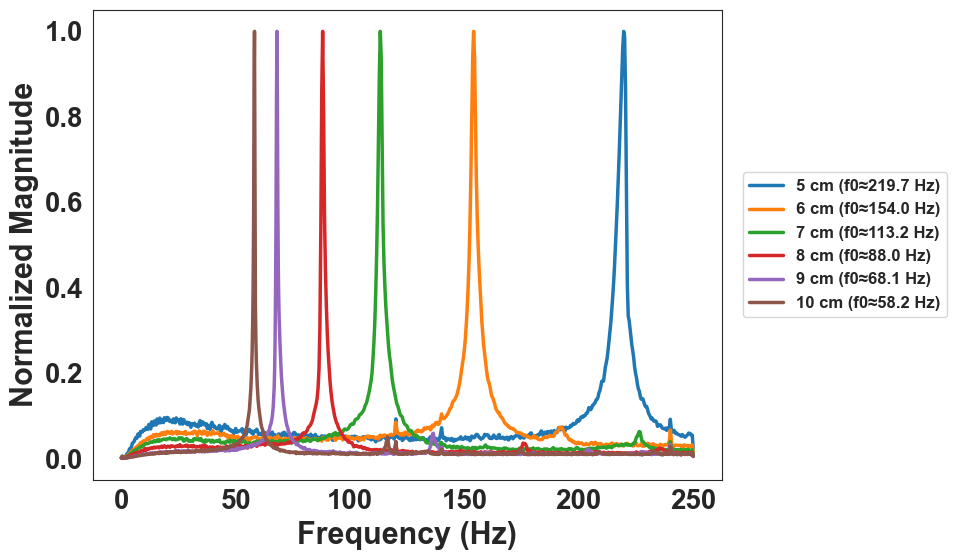

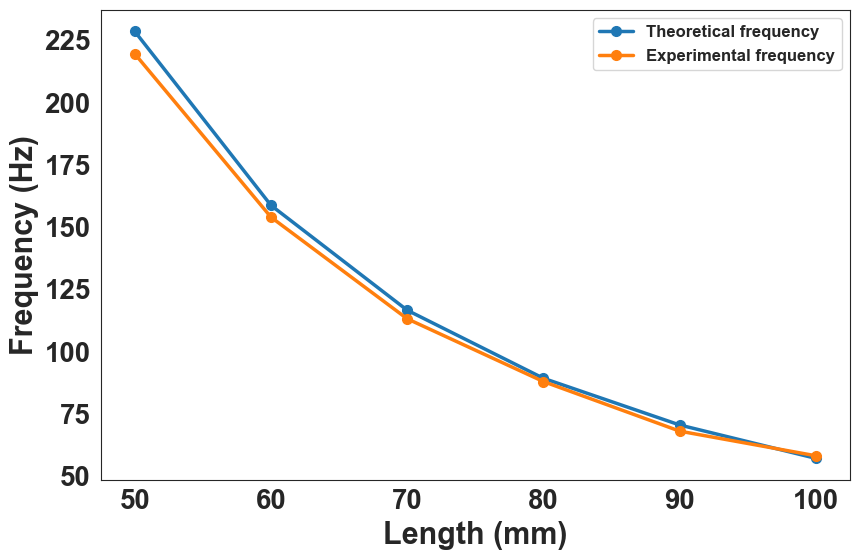

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------
# Global plot style (publication readability)
# ------------------------------------------------
plt.rcParams.update({
    "font.size": 20,
    "font.weight": "bold",
    "axes.titlesize": 22,
    "axes.titleweight": "bold",
    "axes.labelsize": 22,
    "axes.labelweight": "bold",
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 12
})

sns.set_style("white")  # remove grid

# ============================================================
# Frequency processing
# ============================================================

healthy_results_1 = []
healthy_spectra_by_L_1 = {}

for L, (root, final_idx, segs) in LENGTH_CONFIG.items():
    output = average_spectra_by_length(L, root, final_idx, segs)
    if output is None:
        print(f"Files could not be processed for L={L*100:.0f} cm")
        continue

    f0_mean = output["f0_mean"]

    f0_theoretical = cantilever_f_n(L, b_mm=b_mm, h_mm=h_mm, E_GPa=E_GPa, rho=rho, n=1)

    err_pct = abs(f0_mean - f0_theoretical) / f0_theoretical * 100.0 if f0_mean is not None else np.nan

    healthy_results_1.append({
        "Length (mm)": int(round(L * 1000)),
        "f_theoretical (Hz)": f0_theoretical,
        "f_experimental_mean (Hz)": f0_mean,
        "n_segments": output["n_segments"],
        "Relative error (%)": err_pct
    })

    healthy_spectra_by_L_1[L] = output

    print(
        f"L={L*100:.0f} cm | "
        f"f0_exp≈{f0_mean:.3f} Hz | "
        f"f0_theo≈{f0_theoretical:.3f} Hz | "
        f"error={err_pct:.2f}% | n={output['n_segments']}"
    )

# ---- Final table
df = pd.DataFrame(healthy_results_1).sort_values("Length (mm)", ascending=False)

df["f_theoretical (Hz)"] = df["f_theoretical (Hz)"].map(lambda x: round(x, 4))
df["f_experimental_mean (Hz)"] = df["f_experimental_mean (Hz)"].map(lambda x: round(x, 4))
df["Relative error (%)"] = df["Relative error (%)"].map(lambda x: round(x, 4))

print("\n=== Frequency table (by length) ===")
print(df.to_string(index=False))

df.to_csv("healthy_frequency_table.csv", index=False)
print("\nTable saved in: healthy_frequency_table.csv")

# ============================================================
# Graph 1: Average normalized FFT by length
# ============================================================

plt.figure(figsize=(10, 6))

for L, output in sorted(healthy_spectra_by_L_1.items()):
    y = output["fft_avg_norm"].copy()
    ymax = np.max(y)

    if ymax > 0:
        y = y / ymax

    plt.plot(
        output["fft_freqs"],
        y,
        linewidth=2.5,
        label=f"{int(L*100)} cm (f0≈{output['f0_mean']:.1f} Hz)"
    )

# plt.title("Average FFT by Length", fontweight='bold')
plt.xlabel("Frequency (Hz)", fontweight='bold')
plt.ylabel("Normalized Magnitude", fontweight='bold')

plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

plt.grid(False)

plt.tight_layout()
plt.show()

# ============================================================
# Graph 2: Theoretical vs Experimental Frequency
# ============================================================

df_plot = df.sort_values("Length (mm)")

Lm = df_plot["Length (mm)"].to_numpy()
f_theoretical = df_plot["f_theoretical (Hz)"].to_numpy()
f_experimental = df_plot["f_experimental_mean (Hz)"].to_numpy()

plt.figure(figsize=(9, 6))

plt.plot(
    Lm,
    f_theoretical,
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Theoretical frequency"
)

plt.plot(
    Lm,
    f_experimental,
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Experimental frequency"
)

# plt.title("Variation of the Fundamental Frequency with Length", fontweight='bold')
plt.xlabel("Length (mm)", fontweight='bold')
plt.ylabel("Frequency (Hz)", fontweight='bold')

plt.legend()

plt.grid(False)

plt.tight_layout()
plt.show()

Selected file:
C:\Users\axelr\OneDrive\Escritorio\Multitask Learning for Damage Detection and Localization in Beams Using Fiber-Optic Sensors\notebooks\analysis-codes\healthy_beam_lectures\healthy_beam_8cm\ALL0002\F0002CH1.CSV
Estimated f0 for this segment: 88.400 Hz
Estimated period: 0.01131 s


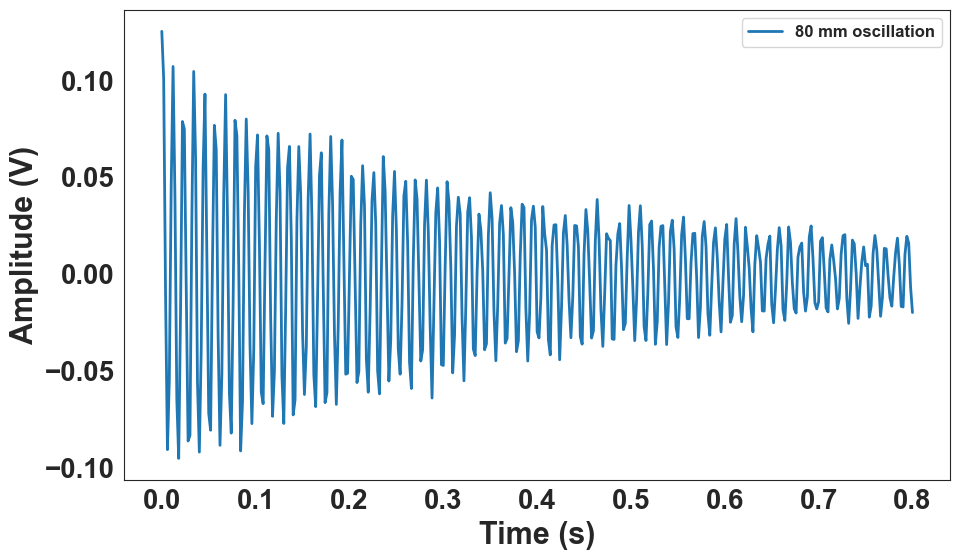

In [6]:
# ============================================================
# Time-domain oscillation for the 80 mm beam
# ============================================================

L_target_m = 0.08       # 80 mm = 8 cm
segment_to_plot = 1     # Use 1 or 2 because 80 mm has 2 perturbations per file
file_to_plot = 2       # 0 = first available file, 1 = second, etc.
zoom_after_excitation_s = 0.8  # seconds after excitation to display

# ------------------------------------------------------------
# Get 80 mm configuration
# ------------------------------------------------------------
root, final_idx, perturbations_per_file = LENGTH_CONFIG[L_target_m]

paths = list_paths(root, final_idx)
existing_paths = [p for p in paths if Path(p).exists()]

if len(existing_paths) == 0:
    raise FileNotFoundError(
        "No CSV files were found for the 80 mm beam. "
        "Check ROOT_1_8 and the folder/file names."
    )

if file_to_plot >= len(existing_paths):
    raise ValueError(
        f"file_to_plot={file_to_plot} is out of range. "
        f"Only {len(existing_paths)} files were found."
    )

path = existing_paths[file_to_plot]

print("Selected file:")
print(path)

# ------------------------------------------------------------
# Load original time-domain signal
# ------------------------------------------------------------
t, v = load_tektronix_csv_columns_DE(path)
fs = compute_fs_from_header_or_time(t, path)

N = len(v)

# ------------------------------------------------------------
# Select segment because 80 mm files have 2 perturbations
# ------------------------------------------------------------
if perturbations_per_file == 2:
    if segment_to_plot == 1:
        i0, i1 = 0, N // 2
    elif segment_to_plot == 2:
        i0, i1 = N // 2, N
    else:
        raise ValueError("segment_to_plot must be 1 or 2.")
else:
    i0, i1 = 0, N

t_seg = t[i0:i1]
v_seg = v[i0:i1]

# Make time start at zero
t_seg = t_seg - t_seg[0]

# Center signal
v_centered = v_seg - np.mean(v_seg)

# Apply the same high-pass filter used in your FFT processing
v_filtered = butter_highpass_filter(v_centered, fs)

# ------------------------------------------------------------
# Estimate f0 from this individual segment
# ------------------------------------------------------------
freqs, mag = fft_single_sided(v_filtered, fs)
f0_seg = estimate_f0_from_spectrum(freqs, mag, FREQ_MIN_HZ)

if f0_seg is not None:
    T0_seg = 1 / f0_seg
    print(f"Estimated f0 for this segment: {f0_seg:.3f} Hz")
    print(f"Estimated period: {T0_seg:.5f} s")
else:
    print("Could not estimate f0 for this segment.")

# ------------------------------------------------------------
# Detect excitation point and zoom after it
# ------------------------------------------------------------
idx_excitation = np.argmax(np.abs(v_filtered))
t_excitation = t_seg[idx_excitation]

mask_zoom = (
    (t_seg >= t_excitation) &
    (t_seg <= t_excitation + zoom_after_excitation_s)
)

# If the detected excitation is too close to the end, plot the full segment
if mask_zoom.sum() < 10:
    mask_zoom = np.ones_like(t_seg, dtype=bool)
    t_plot = t_seg
else:
    t_plot = t_seg[mask_zoom] - t_excitation

v_plot = v_filtered[mask_zoom]

# ------------------------------------------------------------
# Plot oscillation
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    t_plot,
    v_plot,
    linewidth=2.0,
    label=f"80 mm oscillation"
)

plt.xlabel("Time (s)", fontweight="bold")
plt.ylabel("Amplitude (V)", fontweight="bold")

if f0_seg is not None:
    plt.legend(
        frameon=True
    )
else:
    plt.legend(frameon=True)

plt.grid(False)
plt.tight_layout()
plt.show()

Selected healthy file:
C:\Users\axelr\OneDrive\Escritorio\Multitask Learning for Damage Detection and Localization in Beams Using Fiber-Optic Sensors\notebooks\analysis-codes\healthy_beam_lectures\healthy_beam_10cm\ALL0001\F0001CH1.CSV
Selected length: 100 mm
Estimated f0 for this healthy segment: 58.200 Hz
Estimated period: 0.01718 s


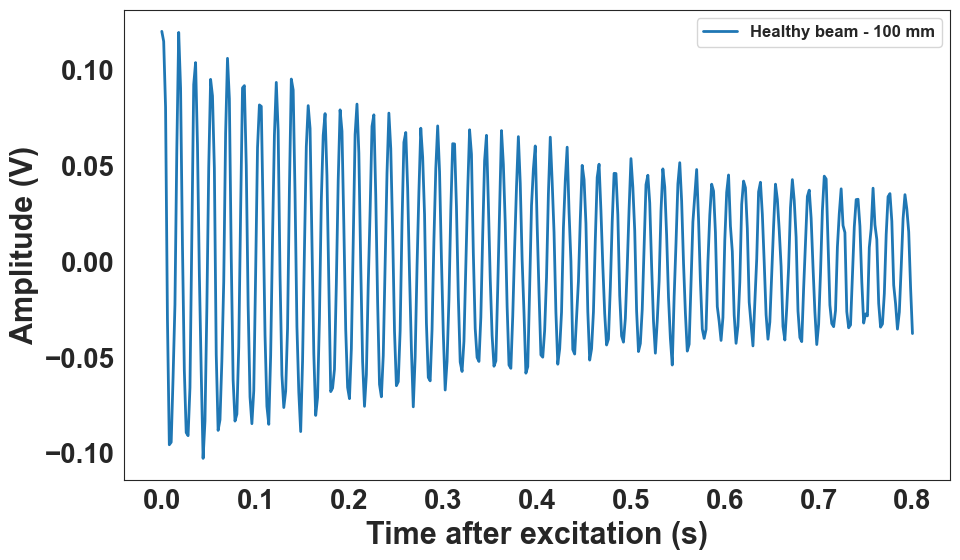

In [7]:
# ============================================================
# Time-domain oscillation for a selected healthy beam
# ============================================================

# -----------------------------
# User parameters
# -----------------------------
L_target_mm = 100          # Available: 50, 60, 70, 80, 90, 100 mm
file_to_plot = 1          # 0 = first available file, 1 = second, etc.
segment_to_plot = 1       # Use 1 or 2 if the file has two perturbations
zoom_after_excitation_s = 0.8

# -----------------------------
# Get selected healthy beam
# -----------------------------
L_target_m = L_target_mm / 1000

available_lengths = np.array(list(LENGTH_CONFIG.keys()))
L_selected = available_lengths[np.argmin(np.abs(available_lengths - L_target_m))]

root, final_idx, perturbations_per_file = LENGTH_CONFIG[L_selected]

paths = list_paths(root, final_idx)
existing_paths = [p for p in paths if Path(p).exists()]

if len(existing_paths) == 0:
    raise FileNotFoundError(
        f"No CSV files were found for the healthy beam of {L_target_mm} mm. "
        "Check the corresponding ROOT path in LENGTH_CONFIG."
    )

if file_to_plot >= len(existing_paths):
    raise ValueError(
        f"file_to_plot={file_to_plot} is out of range. "
        f"Only {len(existing_paths)} files were found."
    )

path = existing_paths[file_to_plot]

print("Selected healthy file:")
print(path)
print(f"Selected length: {L_selected*1000:.0f} mm")

# -----------------------------
# Load original signal
# -----------------------------
t, v = load_tektronix_csv_columns_DE(path)
fs = compute_fs_from_header_or_time(t, path)

N = len(v)

# -----------------------------
# Select segment
# -----------------------------
if perturbations_per_file == 2:
    if segment_to_plot == 1:
        i0, i1 = 0, N // 2
    elif segment_to_plot == 2:
        i0, i1 = N // 2, N
    else:
        raise ValueError("segment_to_plot must be 1 or 2.")
else:
    i0, i1 = 0, N

t_seg = t[i0:i1]
v_seg = v[i0:i1]

# Start time at zero
t_seg = t_seg - t_seg[0]

# Center and filter signal
v_centered = v_seg - np.mean(v_seg)
v_filtered = butter_highpass_filter(v_centered, fs)

# -----------------------------
# Estimate dominant frequency
# -----------------------------
freqs, mag = fft_single_sided(v_filtered, fs)
f0_seg = estimate_f0_from_spectrum(freqs, mag, FREQ_MIN_HZ)

if f0_seg is not None:
    T0_seg = 1 / f0_seg
    print(f"Estimated f0 for this healthy segment: {f0_seg:.3f} Hz")
    print(f"Estimated period: {T0_seg:.5f} s")
else:
    print("Could not estimate f0 for this healthy segment.")

# -----------------------------
# Detect excitation and zoom
# -----------------------------
idx_excitation = np.argmax(np.abs(v_filtered))
t_excitation = t_seg[idx_excitation]

mask_zoom = (
    (t_seg >= t_excitation) &
    (t_seg <= t_excitation + zoom_after_excitation_s)
)

if mask_zoom.sum() < 10:
    mask_zoom = np.ones_like(t_seg, dtype=bool)
    t_plot = t_seg
else:
    t_plot = t_seg[mask_zoom] - t_excitation

v_plot = v_filtered[mask_zoom]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    t_plot,
    v_plot,
    linewidth=2.0,
    label=f"Healthy beam - {int(L_selected*1000)} mm"
)

plt.xlabel("Time after excitation (s)", fontweight="bold")
plt.ylabel("Amplitude (V)", fontweight="bold")

plt.legend(frameon=True)
plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 1 — Imports, physical parameters, and analysis settings
# Fifth version: independent spectral validation + robust
# temporal event alignment without circular shifting
# ============================================================

from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import (
    butter,
    correlate,
    correlation_lags,
    detrend,
    find_peaks,
    hilbert,
    savgol_filter,
    sosfiltfilt,
)
from scipy.stats import pearsonr, theilslopes
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# ------------------------------------------------------------
# Reproducibility and output
# ------------------------------------------------------------

RANDOM_SEED = 2026

VALIDATION_OUTPUT_DIR = Path(
    "optical_model_validation_outputs_v5"
)
VALIDATION_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# ------------------------------------------------------------
# Structural scenarios
# ------------------------------------------------------------

BEAM_LENGTHS_MM = [50, 60, 70, 80, 90, 100]
MAX_SIGNALS_PER_LENGTH = 50

PREFERRED_BETA_CALIBRATION_SIGNALS = 5
MIN_BETA_VALIDATION_SIGNALS = 2

# ------------------------------------------------------------
# Signal-processing settings
# ------------------------------------------------------------

# Signals are analysed at their original oscilloscope sampling
# rate. The expected nominal acquisition rate is reported only
# as a diagnostic and is not imposed by interpolation.
EXPECTED_ACQUISITION_FS_HZ = 500.0
FS_DIAGNOSTIC_TOLERANCE_HZ = 5.0

MAX_ANALYSIS_WINDOW_S = 2.0
FIGURE_WINDOW_S = 0.8

MIN_POST_EXCITATION_S = 0.8
EXCITATION_EDGE_MARGIN_S = 0.03

# The main impact is identified from the largest envelope peak
# inside a safe interval. The response onset is obtained by
# backtracking to a fixed fraction of the peak above the local
# baseline. This avoids selecting small pre-impact fluctuations.
EXCITATION_ONSET_RELATIVE_THRESHOLD = 0.12
EXCITATION_PRETRIGGER_S = 0.01

# After modal filtering, the time-domain response is recentered
# at its first main envelope maximum. Spectral metrics continue
# to use the independently processed broadband response.
MODAL_PEAK_SEARCH_S = 0.30
PHASE_ALIGNMENT_WINDOW_S = 0.15
PHASE_ALIGNMENT_MAX_CYCLES = 0.50
FIGURE_MIN_DECAY_R2 = 0.80

# Frequency quality control is performed only relative to the
# repeated acquisitions within each beam-length group.
FREQUENCY_MAD_Z_THRESHOLD = 3.5

# The modal filter is used only for the time-domain display and
# decay-coefficient estimation. It is not used to calculate the
# spectral correlation or NRMSE.
MODAL_BAND_RELATIVE_HALF_WIDTH = 0.08
MODAL_BAND_MIN_HALF_WIDTH_HZ = 5.0
MODAL_FILTER_ORDER = 4

# The common spectral interval includes both independently
# obtained peaks without shifting or aligning either spectrum.
SPECTRAL_MARGIN_RELATIVE = 0.15
SPECTRAL_MARGIN_MIN_HZ = 10.0
SPECTRAL_GRID_STEP_HZ = 0.10

DECAY_FIT_START_S = 0.03
DECAY_FIT_MAX_S = 0.80
DECAY_MIN_RELATIVE_ENVELOPE = 0.05
DECAY_MIN_FIT_R2 = 0.50
DECAY_BETA_MIN_S_INV = 0.10
DECAY_BETA_MAX_S_INV = 50.0

CORE_DIAMETER_UM = 200.0
W0_UM = CORE_DIAMETER_UM / 2.0
COLLECTION_RADIUS_UM = CORE_DIAMETER_UM / 2.0

NUMERICAL_APERTURE = 0.39
GAMMA_RAD = np.arcsin(NUMERICAL_APERTURE)
GAMMA_DEG = np.degrees(GAMMA_RAD)

MEAN_DISTANCE_MM = 2.0
MEAN_DISTANCE_UM = MEAN_DISTANCE_MM * 1000.0

NOMINAL_DISPLACEMENT_UM = 50.0

KV = 1.0
SIGMA_R = 1.0
I0P = 1.0

print("Output directory:", VALIDATION_OUTPUT_DIR)
print(f"Estimated divergence angle: {GAMMA_DEG:.3f} deg")
print(
    "Frequency extraction:",
    "same independent full-segment FFT procedure used for Figure 5",
)
print(
    "Spectral metrics:",
    "detrended/high-pass experimental signal; no modal band-pass",
)
print(
    "Temporal display:",
    "main-impact onset + modal-envelope peak alignment; no circular shift",
)


Output directory: optical_model_validation_outputs_v5
Estimated divergence angle: 22.954 deg
Frequency extraction: same independent full-segment FFT procedure used for Figure 5
Spectral metrics: detrended/high-pass experimental signal; no modal band-pass
Temporal display: main-impact onset + modal-envelope peak alignment; no circular shift


In [ ]:
# ============================================================
# CELL 2 — Locate the existing healthy-beam files
# ============================================================

HEALTHY_SIGNAL_CONFIG = {}


def _find_length_config_key(length_mm):
    """
    Find a compatible key in an existing LENGTH_CONFIG.
    Common keys include 0.05, 0.06, ..., 0.10 m.
    """
    candidate_values = [
        length_mm,
        length_mm / 10.0,
        length_mm / 1000.0,
    ]

    for candidate in candidate_values:
        if candidate in LENGTH_CONFIG:
            return candidate

    for existing_key in LENGTH_CONFIG:
        try:
            numeric_key = float(existing_key)
        except (TypeError, ValueError):
            continue

        if np.isclose(
            numeric_key,
            length_mm / 1000.0,
            rtol=0,
            atol=1e-9,
        ):
            return existing_key

    raise KeyError(
        f"No LENGTH_CONFIG entry was found for {length_mm} mm."
    )


def resolve_healthy_signal_config():
    """
    Return one configuration record per beam length.

    Each record contains:
        paths
        segments_per_file
    """
    if HEALTHY_SIGNAL_CONFIG:
        resolved = {}

        for length_mm in BEAM_LENGTHS_MM:
            if length_mm not in HEALTHY_SIGNAL_CONFIG:
                raise KeyError(
                    f"HEALTHY_SIGNAL_CONFIG is missing {length_mm} mm."
                )

            entry = HEALTHY_SIGNAL_CONFIG[length_mm]

            resolved[length_mm] = {
                "paths": [
                    Path(path)
                    for path in entry["paths"]
                    if Path(path).exists()
                ],
                "segments_per_file": int(
                    entry.get("segments_per_file", 1)
                ),
            }

        return resolved

    if (
        "LENGTH_CONFIG" not in globals()
        or "list_paths" not in globals()
    ):
        raise RuntimeError(
            "Neither a manual HEALTHY_SIGNAL_CONFIG nor the "
            "existing LENGTH_CONFIG/list_paths environment was found. "
            "Fill HEALTHY_SIGNAL_CONFIG in this cell."
        )

    resolved = {}

    for length_mm in BEAM_LENGTHS_MM:
        config_key = _find_length_config_key(length_mm)
        config_value = LENGTH_CONFIG[config_key]

        if len(config_value) < 3:
            raise ValueError(
                "Each LENGTH_CONFIG entry must contain "
                "(root, final_idx, segments_per_file)."
            )

        root, final_idx, segments_per_file = config_value[:3]

        candidate_paths = [
            Path(path)
            for path in list_paths(root, final_idx)
        ]

        existing_paths = [
            path
            for path in candidate_paths
            if path.exists()
        ]

        resolved[length_mm] = {
            "paths": existing_paths,
            "segments_per_file": int(segments_per_file),
        }

    return resolved


resolved_signal_config = resolve_healthy_signal_config()

print("=== Located healthy-beam files ===")

for length_mm, entry in resolved_signal_config.items():
    print(
        f"{length_mm:>3} mm | "
        f"files={len(entry['paths'])} | "
        f"segments/file={entry['segments_per_file']}"
    )

    if len(entry["paths"]) == 0:
        raise FileNotFoundError(
            f"No existing CSV files were found for {length_mm} mm."
        )

=== Located healthy-beam files ===
 50 mm | files=25 | segments/file=2
 60 mm | files=25 | segments/file=2
 70 mm | files=25 | segments/file=2
 80 mm | files=25 | segments/file=2
 90 mm | files=50 | segments/file=1
100 mm | files=50 | segments/file=1


In [ ]:
# ============================================================
# CELL 3 — Independent frequency extraction, excitation
# detection, temporal modal filtering, decay estimation,
# optical simulation, and unfiltered spectral comparison
# ============================================================

def segment_trace(
    time_values,
    voltage_values,
    segments_per_file,
):
    """
    Divide the oscilloscope record into equal temporal segments,
    following the same segmentation used for Figure 5.
    """
    segments = []

    edges = np.linspace(
        0,
        len(time_values),
        segments_per_file + 1,
        dtype=int,
    )

    for segment_index in range(
        segments_per_file
    ):
        start_index = edges[segment_index]
        end_index = edges[segment_index + 1]

        segment_time = np.asarray(
            time_values[start_index:end_index],
            dtype=float,
        )

        segment_voltage = np.asarray(
            voltage_values[start_index:end_index],
            dtype=float,
        )

        if len(segment_time) < 10:
            continue

        segment_time = (
            segment_time - segment_time[0]
        )

        segments.append(
            (
                segment_index + 1,
                segment_time,
                segment_voltage,
            )
        )

    return segments


def extract_frequency_independently(
    voltage_values,
    sampling_frequency,
):
    """
    Extract the dominant experimental frequency independently
    of the analytical prediction.

    This reproduces the Figure 5 processing:
      1. high-pass filtering,
      2. Hann-windowed single-sided FFT,
    """
    centred_voltage = (
        np.asarray(
            voltage_values,
            dtype=float,
        )
        - np.mean(voltage_values)
    )

    broad_voltage = (
        butter_highpass_filter(
            centred_voltage,
            sampling_frequency,
        )
    )

    frequencies, magnitude = (
        fft_single_sided(
            broad_voltage,
            sampling_frequency,
        )
    )

    experimental_frequency_hz = (
        estimate_f0_from_spectrum(
            frequencies,
            magnitude,
            FREQ_MIN_HZ,
        )
    )

    if experimental_frequency_hz is None:
        experimental_frequency_hz = np.nan

    maximum_absolute = float(
        np.max(
            np.abs(
                broad_voltage
            )
        )
    )

    if (
        not np.isfinite(maximum_absolute)
        or maximum_absolute <= 1e-15
    ):
        raise ValueError(
            "The high-pass-filtered trace has no measurable AC amplitude."
        )

    return {
        "frequency_hz": float(
            experimental_frequency_hz
        ),
        "broad_voltage": (
            broad_voltage
            / maximum_absolute
        ),
        "fft_frequencies_hz": (
            frequencies
        ),
        "fft_magnitude": (
            magnitude
        ),
    }


def _smooth_envelope(
    envelope,
    sampling_frequency,
    smoothing_duration_s=0.04,
):
    envelope = np.asarray(
        envelope,
        dtype=float,
    )

    candidate_window = max(
        5,
        int(
            round(
                smoothing_duration_s
                * sampling_frequency
            )
        ),
    )

    if candidate_window % 2 == 0:
        candidate_window += 1

    maximum_window = (
        len(envelope) - 1
        if len(envelope) % 2 == 0
        else len(envelope)
    )

    smoothing_window = min(
        candidate_window,
        maximum_window,
    )

    if smoothing_window >= 5:
        return savgol_filter(
            envelope,
            window_length=smoothing_window,
            polyorder=2,
            mode="interp",
        )

    return envelope


def detect_excitation_index(
    broad_voltage,
    sampling_frequency,
):
    """
    Detect the main mechanical excitation without using the
    theoretical frequency.

    The largest smoothed-envelope peak is first located inside a
    safe interval that leaves sufficient post-excitation data.
    The onset is then obtained by backtracking from that peak to
    a fixed threshold above the local pre-impact baseline.
    """
    broad_voltage = np.asarray(
        broad_voltage,
        dtype=float,
    )

    smoothed_envelope = _smooth_envelope(
        np.abs(
            hilbert(
                broad_voltage
            )
        ),
        sampling_frequency,
    )

    start_index = max(
        1,
        int(
            round(
                EXCITATION_EDGE_MARGIN_S
                * sampling_frequency
            )
        ),
    )

    required_post_samples = int(
        np.ceil(
            MIN_POST_EXCITATION_S
            * sampling_frequency
        )
    )

    end_index = (
        len(smoothed_envelope)
        - required_post_samples
    )

    if end_index <= start_index:
        raise ValueError(
            "The segment is too short for the required "
            "post-excitation interval."
        )

    safe_envelope = smoothed_envelope[
        start_index:end_index
    ]

    if len(safe_envelope) == 0:
        raise ValueError(
            "No safe excitation-search interval is available."
        )

    relative_peak_index = int(
        np.argmax(
            safe_envelope
        )
    )

    peak_index = int(
        start_index
        + relative_peak_index
    )

    peak_amplitude = float(
        smoothed_envelope[
            peak_index
        ]
    )

    if (
        not np.isfinite(
            peak_amplitude
        )
        or peak_amplitude <= 0
    ):
        raise ValueError(
            "The segment has no measurable vibration response."
        )

    baseline_end_index = max(
        start_index + 1,
        peak_index
        - int(
            round(
                0.10
                * sampling_frequency
            )
        ),
    )

    baseline_values = smoothed_envelope[
        start_index:baseline_end_index
    ]

    if len(baseline_values) == 0:
        baseline_amplitude = float(
            np.median(
                safe_envelope
            )
        )
    else:
        baseline_amplitude = float(
            np.median(
                baseline_values
            )
        )

    onset_threshold = float(
        baseline_amplitude
        + EXCITATION_ONSET_RELATIVE_THRESHOLD
        * (
            peak_amplitude
            - baseline_amplitude
        )
    )

    search_before_peak = smoothed_envelope[
        start_index:peak_index + 1
    ]

    below_threshold_indices = np.where(
        search_before_peak
        <= onset_threshold
    )[0]

    if len(
        below_threshold_indices
    ) > 0:
        onset_index = int(
            start_index
            + below_threshold_indices[-1]
            + 1
        )
    else:
        onset_index = int(
            start_index
        )

    pretrigger_samples = int(
        round(
            EXCITATION_PRETRIGGER_S
            * sampling_frequency
        )
    )

    onset_index = max(
        start_index,
        onset_index
        - pretrigger_samples,
    )

    if (
        len(broad_voltage)
        - onset_index
        < required_post_samples
    ):
        raise ValueError(
            "The detected excitation does not leave enough "
            "post-excitation samples."
        )

    return {
        "onset_index": int(
            onset_index
        ),
        "peak_index": int(
            peak_index
        ),
        "baseline_amplitude": (
            baseline_amplitude
        ),
        "peak_amplitude": (
            peak_amplitude
        ),
        "onset_threshold": (
            onset_threshold
        ),
        "smoothed_envelope": (
            smoothed_envelope
        ),
    }


def prepare_post_excitation_trace(
    time_values,
    broad_voltage,
    sampling_frequency,
):
    time_values = np.asarray(
        time_values,
        dtype=float,
    )

    broad_voltage = np.asarray(
        broad_voltage,
        dtype=float,
    )

    excitation_result = (
        detect_excitation_index(
            broad_voltage,
            sampling_frequency,
        )
    )

    onset_index = excitation_result[
        "onset_index"
    ]

    peak_index = excitation_result[
        "peak_index"
    ]

    post_time = (
        time_values[onset_index:]
        - time_values[onset_index]
    )

    post_voltage = broad_voltage[
        onset_index:
    ]

    if len(post_time) < 10:
        raise ValueError(
            "Insufficient samples after the detected excitation."
        )

    available_duration_s = float(
        post_time[-1]
    )

    if (
        available_duration_s
        < MIN_POST_EXCITATION_S
    ):
        raise ValueError(
            "The available post-excitation interval is too short."
        )

    analysis_duration_s = min(
        MAX_ANALYSIS_WINDOW_S,
        available_duration_s,
    )

    analysis_mask = (
        post_time <= analysis_duration_s
    )

    post_time = post_time[
        analysis_mask
    ]

    post_voltage = post_voltage[
        analysis_mask
    ]

    maximum_absolute = float(
        np.max(
            np.abs(
                post_voltage
            )
        )
    )

    if (
        not np.isfinite(
            maximum_absolute
        )
        or maximum_absolute <= 1e-15
    ):
        raise ValueError(
            "The post-excitation trace has zero AC amplitude."
        )

    return {
        "time": post_time,
        "broad_voltage": (
            post_voltage
            / maximum_absolute
        ),
        "excitation_index": int(
            onset_index
        ),
        "excitation_peak_index": int(
            peak_index
        ),
        "excitation_peak_delay_s": float(
            (
                peak_index
                - onset_index
            )
            / sampling_frequency
        ),
        "excitation_threshold": (
            excitation_result[
                "onset_threshold"
            ]
        ),
    }


def _safe_zero_phase_filter(
    sos,
    signal_values,
):
    try:
        return sosfiltfilt(
            sos,
            signal_values,
        )
    except ValueError:
        return np.asarray(
            signal_values,
            dtype=float,
        )


def apply_modal_band_pass_for_time_domain(
    voltage_values,
    sampling_frequency,
    experimental_frequency_hz,
):
    """
    Isolate the fundamental mode only for the time-domain
    display and decay-coefficient estimation.

    This filtered signal is not used for spectral correlation
    or NRMSE.
    """
    nyquist_hz = (
        sampling_frequency / 2.0
    )

    half_width_hz = max(
        MODAL_BAND_MIN_HALF_WIDTH_HZ,
        MODAL_BAND_RELATIVE_HALF_WIDTH
        * experimental_frequency_hz,
    )

    low_hz = max(
        HIGHPASS_CUTOFF_HZ,
        experimental_frequency_hz
        - half_width_hz,
    )

    high_hz = min(
        nyquist_hz * 0.98,
        experimental_frequency_hz
        + half_width_hz,
    )

    if high_hz <= low_hz:
        raise ValueError(
            "Invalid temporal modal-filter limits."
        )

    sos = butter(
        MODAL_FILTER_ORDER,
        [
            low_hz / nyquist_hz,
            high_hz / nyquist_hz,
        ],
        btype="bandpass",
        output="sos",
    )

    modal_voltage = (
        _safe_zero_phase_filter(
            sos,
            voltage_values,
        )
    )

    modal_voltage = (
        modal_voltage
        - np.mean(
            modal_voltage
        )
    )

    maximum_absolute = float(
        np.max(
            np.abs(
                modal_voltage
            )
        )
    )

    if maximum_absolute <= 1e-15:
        raise ValueError(
            "The temporal modal response has zero amplitude."
        )

    return {
        "voltage": (
            modal_voltage
            / maximum_absolute
        ),
        "low_hz": float(
            low_hz
        ),
        "high_hz": float(
            high_hz
        ),
    }


def prepare_temporal_modal_trace(
    time_values,
    modal_voltage,
    sampling_frequency,
):
    """
    Recenter the modal time-domain response at its first main
    envelope maximum.
    """
    time_values = np.asarray(
        time_values,
        dtype=float,
    )

    modal_voltage = np.asarray(
        modal_voltage,
        dtype=float,
    )

    if len(time_values) != len(
        modal_voltage
    ):
        raise ValueError(
            "Time and modal-voltage arrays must have equal length."
        )

    modal_envelope = _smooth_envelope(
        np.abs(
            hilbert(
                modal_voltage
            )
        ),
        sampling_frequency,
        smoothing_duration_s=0.04,
    )

    maximum_search_samples = min(
        len(modal_envelope),
        max(
            2,
            int(
                round(
                    MODAL_PEAK_SEARCH_S
                    * sampling_frequency
                )
            ),
        ),
    )

    required_display_samples = int(
        np.ceil(
            FIGURE_WINDOW_S
            * sampling_frequency
        )
    )

    latest_valid_peak_index = max(
        1,
        len(modal_envelope)
        - required_display_samples,
    )

    search_end_index = min(
        maximum_search_samples,
        latest_valid_peak_index + 1,
    )

    if search_end_index <= 1:
        raise ValueError(
            "The modal response is too short for temporal alignment."
        )

    modal_peak_index = int(
        np.argmax(
            modal_envelope[
                :search_end_index
            ]
        )
    )

    temporal_time = (
        time_values[
            modal_peak_index:
        ]
        - time_values[
            modal_peak_index
        ]
    )

    temporal_voltage = modal_voltage[
        modal_peak_index:
    ]

    if (
        len(temporal_time)
        < required_display_samples
    ):
        raise ValueError(
            "Insufficient modal samples after the envelope peak."
        )

    display_mask = (
        temporal_time
        <= FIGURE_WINDOW_S
    )

    display_scale = float(
        np.max(
            np.abs(
                temporal_voltage[
                    display_mask
                ]
            )
        )
    )

    if (
        not np.isfinite(
            display_scale
        )
        or display_scale <= 1e-15
    ):
        raise ValueError(
            "The aligned modal response has zero display amplitude."
        )

    temporal_voltage = (
        temporal_voltage
        / display_scale
    )

    return {
        "time": temporal_time,
        "voltage": temporal_voltage,
        "modal_peak_index": int(
            modal_peak_index
        ),
        "modal_peak_delay_s": float(
            time_values[
                modal_peak_index
            ]
            - time_values[0]
        ),
        "modal_envelope": (
            modal_envelope[
                modal_peak_index:
            ]
        ),
    }


def robust_frequency_inlier_mask(
    frequencies_hz,
):
    """
    Modified-z-score quality control based only on the
    distribution of repeated measurements within one length.
    """
    values = np.asarray(
        frequencies_hz,
        dtype=float,
    )

    finite_mask = np.isfinite(
        values
    )

    if finite_mask.sum() < 3:
        return finite_mask

    finite_values = values[
        finite_mask
    ]

    median_value = float(
        np.median(
            finite_values
        )
    )

    mad_value = float(
        np.median(
            np.abs(
                finite_values
                - median_value
            )
        )
    )

    if mad_value <= 1e-12:
        inlier_finite = np.isclose(
            finite_values,
            median_value,
            rtol=0.0,
            atol=max(
                0.5,
                0.01 * median_value,
            ),
        )
    else:
        modified_z = (
            0.6745
            * (
                finite_values
                - median_value
            )
            / mad_value
        )

        inlier_finite = (
            np.abs(
                modified_z
            )
            <= FREQUENCY_MAD_Z_THRESHOLD
        )

    result = np.zeros(
        len(values),
        dtype=bool,
    )

    result[
        np.where(
            finite_mask
        )[0]
    ] = inlier_finite

    return result


def estimate_decay_rate(
    time_values,
    temporal_modal_voltage,
):
    """
    Estimate beta from the isolated temporal fundamental mode.
    """
    time_values = np.asarray(
        time_values,
        dtype=float,
    )

    modal_voltage = np.asarray(
        temporal_modal_voltage,
        dtype=float,
    )

    sampling_frequency = float(
        1.0
        / np.median(
            np.diff(
                time_values
            )
        )
    )

    envelope = np.abs(
        hilbert(
            modal_voltage
        )
    )

    maximum_envelope = float(
        np.max(
            envelope
        )
    )

    if maximum_envelope <= 0:
        return {
            "beta_s_inv": np.nan,
            "fit_r2": np.nan,
            "envelope": envelope,
            "n_fit_points": 0,
        }

    normalized_envelope = (
        envelope
        / maximum_envelope
    )

    smoothed_envelope = (
        _smooth_envelope(
            normalized_envelope,
            sampling_frequency,
            smoothing_duration_s=0.05,
        )
    )

    smoothed_envelope = np.clip(
        smoothed_envelope,
        1e-9,
        None,
    )

    fit_mask = (
        (time_values >= DECAY_FIT_START_S)
        & (time_values <= DECAY_FIT_MAX_S)
        & (
            smoothed_envelope
            >= DECAY_MIN_RELATIVE_ENVELOPE
        )
        & (
            smoothed_envelope
            <= 1.05
        )
    )

    number_fit_points = int(
        fit_mask.sum()
    )

    if number_fit_points < 20:
        return {
            "beta_s_inv": np.nan,
            "fit_r2": np.nan,
            "envelope": smoothed_envelope,
            "n_fit_points": number_fit_points,
        }

    fit_time = time_values[
        fit_mask
    ]

    fit_log_envelope = np.log(
        smoothed_envelope[
            fit_mask
        ]
    )

    slope, intercept, _, _ = (
        theilslopes(
            fit_log_envelope,
            fit_time,
            alpha=0.95,
        )
    )

    predicted_log_envelope = (
        intercept
        + slope * fit_time
    )

    residual_sum_squares = float(
        np.sum(
            (
                fit_log_envelope
                - predicted_log_envelope
            )**2
        )
    )

    total_sum_squares = float(
        np.sum(
            (
                fit_log_envelope
                - np.mean(
                    fit_log_envelope
                )
            )**2
        )
    )

    fit_r2 = (
        np.nan
        if total_sum_squares <= 0
        else float(
            1.0
            - residual_sum_squares
            / total_sum_squares
        )
    )

    beta_s_inv = float(
        -slope
    )

    if (
        not np.isfinite(
            beta_s_inv
        )
        or beta_s_inv
        < DECAY_BETA_MIN_S_INV
        or beta_s_inv
        > DECAY_BETA_MAX_S_INV
    ):
        beta_s_inv = np.nan

    return {
        "beta_s_inv": (
            beta_s_inv
        ),
        "fit_r2": (
            fit_r2
        ),
        "envelope": (
            smoothed_envelope
        ),
        "n_fit_points": (
            number_fit_points
        ),
    }


def theoretical_frequency_for_length(
    length_mm,
):
    """
    Use exactly the Euler-Bernoulli implementation already
    employed by the Figure 5 analysis.
    """
    return float(
        cantilever_f_n(
            length_mm / 1000.0,
            b_mm=b_mm,
            h_mm=h_mm,
            E_GPa=E_GPa,
            rho=rho,
            n=1,
        )
    )


def normalized_zero_padded_spectrum(
    voltage_values,
    sampling_frequency,
    n_fft=None,
):
    voltage_values = detrend(
        np.asarray(
            voltage_values,
            dtype=float,
        ),
        type="linear",
    )

    number_samples = len(
        voltage_values
    )

    if n_fft is None:
        n_fft = max(
            4096,
            2 ** int(
                np.ceil(
                    np.log2(
                        number_samples
                    )
                )
            ),
        )

    window = np.hanning(
        number_samples
    )

    spectrum = np.fft.rfft(
        voltage_values * window,
        n=n_fft,
    )

    magnitude = np.abs(
        spectrum
    )

    frequencies = np.fft.rfftfreq(
        n_fft,
        d=1.0 / sampling_frequency,
    )

    maximum_magnitude = float(
        np.max(
            magnitude
        )
    )

    if maximum_magnitude > 0:
        magnitude = (
            magnitude
            / maximum_magnitude
        )

    return frequencies, magnitude


def simulate_normalized_optical_response(
    time_values,
    theoretical_frequency_hz,
    decay_rate_s_inv,
):
    time_values = np.asarray(
        time_values,
        dtype=float,
    )

    angular_frequency = (
        2.0
        * np.pi
        * theoretical_frequency_hz
    )

    damping_ratio = float(
        np.clip(
            decay_rate_s_inv
            / angular_frequency,
            0.0,
            0.30,
        )
    )

    damped_frequency_hz = (
        theoretical_frequency_hz
        * np.sqrt(
            1.0
            - damping_ratio**2
        )
    )

    displacement_um = (
        NOMINAL_DISPLACEMENT_UM
        * np.exp(
            -decay_rate_s_inv
            * time_values
        )
        * np.sin(
            2.0
            * np.pi
            * damped_frequency_hz
            * time_values
        )
    )

    instantaneous_distance_um = (
        MEAN_DISTANCE_UM
        + displacement_um
    )

    omega_um = (
        W0_UM
        + 2.0
        * instantaneous_distance_um
        * np.tan(
            GAMMA_RAD
        )
    )

    collection_fraction = (
        1.0
        - np.exp(
            -(
                COLLECTION_RADIUS_UM**2
            )
            / (
                2.0
                * omega_um**2
            )
        )
    )

    simulated_output = (
        KV
        * SIGMA_R
        * I0P
        * collection_fraction
    )

    simulated_ac = (
        simulated_output
        - np.mean(
            simulated_output
        )
    )

    maximum_absolute = float(
        np.max(
            np.abs(
                simulated_ac
            )
        )
    )

    if maximum_absolute <= 0:
        raise ValueError(
            "The simulated optical response has zero AC amplitude."
        )

    return {
        "voltage": (
            simulated_ac
            / maximum_absolute
        ),
        "damping_ratio": (
            damping_ratio
        ),
        "damped_frequency_hz": float(
            damped_frequency_hz
        ),
    }


def compare_unfiltered_local_spectra(
    experimental_broad_voltage,
    simulated_voltage,
    sampling_frequency,
    experimental_frequency_hz,
    theoretical_frequency_hz,
):

    (
        experimental_frequencies,
        experimental_magnitude,
    ) = normalized_zero_padded_spectrum(
        experimental_broad_voltage,
        sampling_frequency,
    )

    (
        simulated_frequencies,
        simulated_magnitude,
    ) = normalized_zero_padded_spectrum(
        simulated_voltage,
        sampling_frequency,
    )

    nyquist_hz = (
        sampling_frequency / 2.0
    )

    margin_hz = max(
        SPECTRAL_MARGIN_MIN_HZ,
        SPECTRAL_MARGIN_RELATIVE
        * max(
            experimental_frequency_hz,
            theoretical_frequency_hz,
        ),
    )

    lower_hz = max(
        HIGHPASS_CUTOFF_HZ,
        min(
            experimental_frequency_hz,
            theoretical_frequency_hz,
        )
        - margin_hz,
    )

    upper_hz = min(
        nyquist_hz * 0.995,
        max(
            experimental_frequency_hz,
            theoretical_frequency_hz,
        )
        + margin_hz,
    )

    if upper_hz <= lower_hz:
        raise ValueError(
            "Invalid common spectral-comparison interval."
        )

    common_frequency_grid = np.arange(
        lower_hz,
        upper_hz
        + SPECTRAL_GRID_STEP_HZ / 2.0,
        SPECTRAL_GRID_STEP_HZ,
    )

    experimental_interpolated = np.interp(
        common_frequency_grid,
        experimental_frequencies,
        experimental_magnitude,
    )

    simulated_interpolated = np.interp(
        common_frequency_grid,
        simulated_frequencies,
        simulated_magnitude,
    )

    if (
        np.std(
            experimental_interpolated
        ) <= 0
        or np.std(
            simulated_interpolated
        ) <= 0
    ):
        spectral_correlation = np.nan
    else:
        spectral_correlation = float(
            pearsonr(
                experimental_interpolated,
                simulated_interpolated,
            )[0]
        )

    spectral_rmse = float(
        np.sqrt(
            np.mean(
                (
                    experimental_interpolated
                    - simulated_interpolated
                )**2
            )
        )
    )

    experimental_range = float(
        np.ptp(
            experimental_interpolated
        )
    )

    spectral_nrmse = (
        np.nan
        if experimental_range <= 0
        else float(
            spectral_rmse
            / experimental_range
        )
    )

    return {
        "spectral_correlation": (
            spectral_correlation
        ),
        "spectral_nrmse": (
            spectral_nrmse
        ),
        "frequency_grid_hz": (
            common_frequency_grid
        ),
        "experimental_spectrum": (
            experimental_interpolated
        ),
        "simulated_spectrum": (
            simulated_interpolated
        ),
        "spectral_low_hz": float(
            lower_hz
        ),
        "spectral_high_hz": float(
            upper_hz
        ),
    }


def normalize_in_display_window(
    time_values,
    voltage_values,
    display_window_s=FIGURE_WINDOW_S,
):
    time_values = np.asarray(
        time_values,
        dtype=float,
    )

    voltage_values = np.asarray(
        voltage_values,
        dtype=float,
    )

    display_mask = (
        time_values <= display_window_s
    )

    scale_value = float(
        np.max(
            np.abs(
                voltage_values[
                    display_mask
                ]
            )
        )
    )

    if scale_value <= 0:
        return voltage_values

    return (
        voltage_values
        / scale_value
    )


def phase_align_simulation_for_display(
    experimental_voltage,
    simulated_voltage,
    sampling_frequency,
    experimental_frequency_hz,
):
    experimental_voltage = np.asarray(
        experimental_voltage,
        dtype=float,
    )

    simulated_voltage = np.asarray(
        simulated_voltage,
        dtype=float,
    )

    common_length = min(
        len(experimental_voltage),
        len(simulated_voltage),
    )

    experimental_voltage = (
        experimental_voltage[
            :common_length
        ]
    )

    simulated_voltage = (
        simulated_voltage[
            :common_length
        ]
    )

    alignment_samples = min(
        common_length,
        max(
            3,
            int(
                round(
                    PHASE_ALIGNMENT_WINDOW_S
                    * sampling_frequency
                )
            ),
        ),
    )

    experimental_window = (
        experimental_voltage[
            :alignment_samples
        ]
        - np.mean(
            experimental_voltage[
                :alignment_samples
            ]
        )
    )

    simulated_window = (
        simulated_voltage[
            :alignment_samples
        ]
        - np.mean(
            simulated_voltage[
                :alignment_samples
            ]
        )
    )

    cross_correlation = correlate(
        experimental_window,
        simulated_window,
        mode="full",
    )

    lags = correlation_lags(
        len(experimental_window),
        len(simulated_window),
        mode="full",
    )

    maximum_lag_samples = max(
        1,
        int(
            round(
                PHASE_ALIGNMENT_MAX_CYCLES
                * sampling_frequency
                / experimental_frequency_hz
            )
        ),
    )

    allowed_lag_mask = (
        np.abs(
            lags
        )
        <= maximum_lag_samples
    )

    allowed_lags = lags[
        allowed_lag_mask
    ]

    allowed_correlation = (
        cross_correlation[
            allowed_lag_mask
        ]
    )

    best_lag = int(
        allowed_lags[
            np.argmax(
                allowed_correlation
            )
        ]
    )

    aligned_simulation = np.full(
        common_length,
        np.nan,
        dtype=float,
    )

    if best_lag > 0:
        aligned_simulation[
            best_lag:
        ] = simulated_voltage[
            :common_length
            - best_lag
        ]

    elif best_lag < 0:
        shift = abs(
            best_lag
        )

        aligned_simulation[
            :common_length
            - shift
        ] = simulated_voltage[
            shift:
        ]

    else:
        aligned_simulation[:] = (
            simulated_voltage
        )

    return {
        "voltage": (
            aligned_simulation
        ),
        "lag_samples": int(
            best_lag
        ),
        "lag_seconds": float(
            best_lag
            / sampling_frequency
        ),
    }


In [11]:
# ============================================================
# CELL 4 — Prepare traces using independent frequency
# extraction and robust temporal event alignment
# ============================================================

all_trace_records = []
skipped_trace_records = []

for length_mm in BEAM_LENGTHS_MM:
    entry = resolved_signal_config[
        length_mm
    ]

    theoretical_frequency_hz = (
        theoretical_frequency_for_length(
            length_mm
        )
    )

    for csv_path in sorted(
        entry["paths"],
        key=lambda path: str(path),
    ):
        try:
            time_values, voltage_values = (
                load_tektronix_csv_columns_DE(
                    csv_path
                )
            )

            sampling_frequency = (
                compute_fs_from_header_or_time(
                    time_values,
                    csv_path,
                )
            )

            segmented_traces = segment_trace(
                time_values,
                voltage_values,
                entry["segments_per_file"],
            )

        except Exception as error:
            skipped_trace_records.append({
                "length_mm": int(
                    length_mm
                ),
                "file_path": str(
                    csv_path
                ),
                "segment_id": np.nan,
                "reason": str(
                    error
                ),
            })
            continue

        for (
            segment_id,
            segment_time,
            segment_voltage,
        ) in segmented_traces:
            try:
                frequency_result = (
                    extract_frequency_independently(
                        segment_voltage,
                        sampling_frequency,
                    )
                )

                experimental_frequency_hz = (
                    frequency_result[
                        "frequency_hz"
                    ]
                )

                if not np.isfinite(
                    experimental_frequency_hz
                ):
                    raise ValueError(
                        "No independent experimental peak was extracted."
                    )

                post_result = (
                    prepare_post_excitation_trace(
                        segment_time,
                        frequency_result[
                            "broad_voltage"
                        ],
                        sampling_frequency,
                    )
                )

                modal_result = (
                    apply_modal_band_pass_for_time_domain(
                        post_result[
                            "broad_voltage"
                        ],
                        sampling_frequency,
                        experimental_frequency_hz,
                    )
                )

                temporal_result = (
                    prepare_temporal_modal_trace(
                        post_result[
                            "time"
                        ],
                        modal_result[
                            "voltage"
                        ],
                        sampling_frequency,
                    )
                )

                decay_result = (
                    estimate_decay_rate(
                        temporal_result[
                            "time"
                        ],
                        temporal_result[
                            "voltage"
                        ],
                    )
                )

                all_trace_records.append({
                    "length_mm": int(
                        length_mm
                    ),
                    "file_path": str(
                        csv_path
                    ),
                    "segment_id": int(
                        segment_id
                    ),
                    "sampling_frequency_hz": float(
                        sampling_frequency
                    ),
                    "time": post_result[
                        "time"
                    ],
                    "temporal_time": (
                        temporal_result[
                            "time"
                        ]
                    ),
                    "experimental_broad_voltage": (
                        post_result[
                            "broad_voltage"
                        ]
                    ),
                    "experimental_modal_voltage": (
                        temporal_result[
                            "voltage"
                        ]
                    ),
                    "excitation_index": (
                        post_result[
                            "excitation_index"
                        ]
                    ),
                    "excitation_peak_index": (
                        post_result[
                            "excitation_peak_index"
                        ]
                    ),
                    "excitation_peak_delay_s": (
                        post_result[
                            "excitation_peak_delay_s"
                        ]
                    ),
                    "modal_peak_delay_s": (
                        temporal_result[
                            "modal_peak_delay_s"
                        ]
                    ),
                    "theoretical_frequency_hz": (
                        theoretical_frequency_hz
                    ),
                    "experimental_frequency_hz": (
                        experimental_frequency_hz
                    ),
                    "modal_low_hz": (
                        modal_result[
                            "low_hz"
                        ]
                    ),
                    "modal_high_hz": (
                        modal_result[
                            "high_hz"
                        ]
                    ),
                    "experimental_beta_s_inv": (
                        decay_result[
                            "beta_s_inv"
                        ]
                    ),
                    "decay_fit_r2": (
                        decay_result[
                            "fit_r2"
                        ]
                    ),
                    "decay_fit_points": (
                        decay_result[
                            "n_fit_points"
                        ]
                    ),
                })

            except Exception as error:
                skipped_trace_records.append({
                    "length_mm": int(
                        length_mm
                    ),
                    "file_path": str(
                        csv_path
                    ),
                    "segment_id": int(
                        segment_id
                    ),
                    "reason": str(
                        error
                    ),
                })


selected_trace_records = []
frequency_quality_rows = []
frequency_outlier_rows = []

for length_mm in BEAM_LENGTHS_MM:
    length_records = sorted(
        [
            record
            for record in all_trace_records
            if (
                record["length_mm"]
                == length_mm
            )
        ],
        key=lambda record: (
            record["file_path"],
            record["segment_id"],
        ),
    )[:MAX_SIGNALS_PER_LENGTH]

    frequencies_hz = np.array(
        [
            record[
                "experimental_frequency_hz"
            ]
            for record in length_records
        ],
        dtype=float,
    )

    inlier_mask = (
        robust_frequency_inlier_mask(
            frequencies_hz
        )
    )

    median_frequency_hz = float(
        np.nanmedian(
            frequencies_hz
        )
    )

    mad_frequency_hz = float(
        np.nanmedian(
            np.abs(
                frequencies_hz
                - median_frequency_hz
            )
        )
    )

    for record, is_inlier in zip(
        length_records,
        inlier_mask,
    ):
        record[
            "frequency_inlier"
        ] = bool(
            is_inlier
        )

        if is_inlier:
            selected_trace_records.append(
                record
            )
        else:
            frequency_outlier_rows.append({
                "length_mm": int(
                    length_mm
                ),
                "file_path": record[
                    "file_path"
                ],
                "segment_id": record[
                    "segment_id"
                ],
                "experimental_frequency_hz": (
                    record[
                        "experimental_frequency_hz"
                    ]
                ),
                "group_median_frequency_hz": (
                    median_frequency_hz
                ),
                "group_mad_frequency_hz": (
                    mad_frequency_hz
                ),
            })

    length_sampling_rates = np.array(
        [
            record[
                "sampling_frequency_hz"
            ]
            for record in length_records
        ],
        dtype=float,
    )

    frequency_quality_rows.append({
        "length_mm": int(
            length_mm
        ),
        "prepared_before_consistency_qc": int(
            len(length_records)
        ),
        "frequency_inliers": int(
            inlier_mask.sum()
        ),
        "frequency_outliers": int(
            len(length_records)
            - inlier_mask.sum()
        ),
        "frequency_median_hz": (
            median_frequency_hz
        ),
        "frequency_mad_hz": (
            mad_frequency_hz
        ),
        "sampling_frequency_mean_hz": float(
            np.mean(
                length_sampling_rates
            )
        ),
        "sampling_frequency_min_hz": float(
            np.min(
                length_sampling_rates
            )
        ),
        "sampling_frequency_max_hz": float(
            np.max(
                length_sampling_rates
            )
        ),
    })


df_frequency_quality = pd.DataFrame(
    frequency_quality_rows
)

df_frequency_outliers = pd.DataFrame(
    frequency_outlier_rows
)

df_skipped_traces = pd.DataFrame(
    skipped_trace_records
)

print(
    "=== Independent frequency consistency assessment ==="
)
display(
    df_frequency_quality
)

if not df_frequency_outliers.empty:
    print(
        "\n=== Frequency estimates excluded by within-group MAD ==="
    )
    display(
        df_frequency_outliers
    )

if not df_skipped_traces.empty:
    print(
        "\n=== Skipped-trace summary ==="
    )
    display(
        df_skipped_traces
        .groupby(
            [
                "length_mm",
                "reason",
            ],
            dropna=False,
        )
        .size()
        .reset_index(
            name="count"
        )
    )

frequency_quality_path = (
    VALIDATION_OUTPUT_DIR
    / "optical_validation_frequency_quality_v5.csv"
)

frequency_outliers_path = (
    VALIDATION_OUTPUT_DIR
    / "optical_validation_frequency_outliers_v5.csv"
)

skipped_traces_path = (
    VALIDATION_OUTPUT_DIR
    / "optical_validation_skipped_traces_v5.csv"
)

df_frequency_quality.to_csv(
    frequency_quality_path,
    index=False,
)

df_frequency_outliers.to_csv(
    frequency_outliers_path,
    index=False,
)

df_skipped_traces.to_csv(
    skipped_traces_path,
    index=False,
)

print(
    "\n=== Diagnostic exports ==="
)
print(
    frequency_quality_path
)
print(
    frequency_outliers_path
)
print(
    skipped_traces_path
)


=== Independent frequency consistency assessment ===


,length_mm,prepared_before_consistency_qc,frequency_inliers,frequency_outliers,frequency_median_hz,frequency_mad_hz,sampling_frequency_mean_hz,sampling_frequency_min_hz,sampling_frequency_max_hz
0,50,50,50,0,219.6,0.4,500.0,500.0,500.0
1,60,50,50,0,154.0,0.0,500.0,500.0,500.0
2,70,50,50,0,113.2,0.0,500.0,500.0,500.0
3,80,50,50,0,88.0,0.0,500.0,500.0,500.0
4,90,50,50,0,68.0,0.0,500.0,500.0,500.0
5,100,50,50,0,58.2,0.0,500.0,500.0,500.0



=== Diagnostic exports ===
optical_model_validation_outputs_v5\optical_validation_frequency_quality_v5.csv
optical_model_validation_outputs_v5\optical_validation_frequency_outliers_v5.csv
optical_model_validation_outputs_v5\optical_validation_skipped_traces_v5.csv


In [ ]:
rng = np.random.default_rng(
    RANDOM_SEED
)

validation_rows = []
calibration_rows = []

for length_mm in BEAM_LENGTHS_MM:
    length_records = [
        record
        for record in selected_trace_records
        if (
            record["length_mm"]
            == length_mm
        )
    ]

    if len(length_records) == 0:
        raise RuntimeError(
            f"No accepted records are available for {length_mm} mm."
        )

    theoretical_frequency_hz = float(
        length_records[0][
            "theoretical_frequency_hz"
        ]
    )

    beta_quality_records = [
        record
        for record in length_records
        if (
            np.isfinite(
                record[
                    "experimental_beta_s_inv"
                ]
            )
            and np.isfinite(
                record[
                    "decay_fit_r2"
                ]
            )
            and record[
                "decay_fit_r2"
            ] >= DECAY_MIN_FIT_R2
        )
    ]

    if (
        len(beta_quality_records)
        >= (
            PREFERRED_BETA_CALIBRATION_SIGNALS
            + MIN_BETA_VALIDATION_SIGNALS
        )
    ):
        n_beta_calibration = (
            PREFERRED_BETA_CALIBRATION_SIGNALS
        )

    elif len(beta_quality_records) >= 4:
        n_beta_calibration = max(
            2,
            len(beta_quality_records)
            - MIN_BETA_VALIDATION_SIGNALS,
        )

    elif len(beta_quality_records) >= 1:
        n_beta_calibration = len(
            beta_quality_records
        )

    else:
        n_beta_calibration = 0

    if n_beta_calibration > 0:
        shuffled_indices = rng.permutation(
            len(
                beta_quality_records
            )
        )

        calibration_records = [
            beta_quality_records[
                index
            ]
            for index in shuffled_indices[
                :n_beta_calibration
            ]
        ]

        calibrated_beta_s_inv = float(
            np.median(
                [
                    record[
                        "experimental_beta_s_inv"
                    ]
                    for record
                    in calibration_records
                ]
            )
        )

        beta_source = (
            "experimental_temporal_modal_envelope"
        )

    else:
        calibration_records = []

        calibrated_beta_s_inv = float(
            0.03
            * 2.0
            * np.pi
            * theoretical_frequency_hz
        )

        beta_source = (
            "fallback_zeta_0.03"
        )

    calibration_keys = {
        (
            record[
                "file_path"
            ],
            record[
                "segment_id"
            ],
        )
        for record in calibration_records
    }

    validation_records = [
        record
        for record in length_records
        if (
            record[
                "file_path"
            ],
            record[
                "segment_id"
            ],
        ) not in calibration_keys
    ]

    calibration_rows.append({
        "length_mm": int(
            length_mm
        ),
        "accepted_frequency_signals": int(
            len(
                length_records
            )
        ),
        "valid_beta_quality_signals": int(
            len(
                beta_quality_records
            )
        ),
        "n_beta_calibration": int(
            len(
                calibration_records
            )
        ),
        "n_independent_validation": int(
            len(
                validation_records
            )
        ),
        "calibrated_beta_s_inv": (
            calibrated_beta_s_inv
        ),
        "calibrated_zeta": float(
            calibrated_beta_s_inv
            / (
                2.0
                * np.pi
                * theoretical_frequency_hz
            )
        ),
        "beta_source": (
            beta_source
        ),
    })

    for validation_index, record in enumerate(
        validation_records,
        start=1,
    ):
        spectral_simulation = (
            simulate_normalized_optical_response(
                record[
                    "time"
                ],
                theoretical_frequency_hz,
                calibrated_beta_s_inv,
            )
        )

        temporal_simulation = (
            simulate_normalized_optical_response(
                record[
                    "temporal_time"
                ],
                theoretical_frequency_hz,
                calibrated_beta_s_inv,
            )
        )

        spectral_comparison = (
            compare_unfiltered_local_spectra(
                record[
                    "experimental_broad_voltage"
                ],
                spectral_simulation[
                    "voltage"
                ],
                record[
                    "sampling_frequency_hz"
                ],
                record[
                    "experimental_frequency_hz"
                ],
                theoretical_frequency_hz,
            )
        )

        validation_rows.append({
            "length_mm": int(
                length_mm
            ),
            "validation_index": int(
                validation_index
            ),
            "file_path": record[
                "file_path"
            ],
            "segment_id": record[
                "segment_id"
            ],
            "sampling_frequency_hz": (
                record[
                    "sampling_frequency_hz"
                ]
            ),
            "theoretical_frequency_hz": (
                theoretical_frequency_hz
            ),
            "experimental_frequency_hz": (
                record[
                    "experimental_frequency_hz"
                ]
            ),
            "calibrated_beta_s_inv": (
                calibrated_beta_s_inv
            ),
            "spectral_correlation": (
                spectral_comparison[
                    "spectral_correlation"
                ]
            ),
            "spectral_nrmse": (
                spectral_comparison[
                    "spectral_nrmse"
                ]
            ),
            "spectral_low_hz": (
                spectral_comparison[
                    "spectral_low_hz"
                ]
            ),
            "spectral_high_hz": (
                spectral_comparison[
                    "spectral_high_hz"
                ]
            ),
            "modal_low_hz": (
                record[
                    "modal_low_hz"
                ]
            ),
            "modal_high_hz": (
                record[
                    "modal_high_hz"
                ]
            ),
            "time": record[
                "time"
            ],
            "temporal_time": (
                record[
                    "temporal_time"
                ]
            ),
            "experimental_broad_voltage": (
                record[
                    "experimental_broad_voltage"
                ]
            ),
            "experimental_modal_voltage": (
                record[
                    "experimental_modal_voltage"
                ]
            ),
            "simulated_voltage": (
                spectral_simulation[
                    "voltage"
                ]
            ),
            "simulated_temporal_voltage": (
                temporal_simulation[
                    "voltage"
                ]
            ),
            "excitation_peak_delay_s": (
                record[
                    "excitation_peak_delay_s"
                ]
            ),
            "modal_peak_delay_s": (
                record[
                    "modal_peak_delay_s"
                ]
            ),
            "experimental_beta_s_inv": (
                record[
                    "experimental_beta_s_inv"
                ]
            ),
            "decay_fit_r2": (
                record[
                    "decay_fit_r2"
                ]
            ),
            "frequency_grid_hz": (
                spectral_comparison[
                    "frequency_grid_hz"
                ]
            ),
            "experimental_spectrum": (
                spectral_comparison[
                    "experimental_spectrum"
                ]
            ),
            "simulated_spectrum": (
                spectral_comparison[
                    "simulated_spectrum"
                ]
            ),
            "simulated_damping_ratio": (
                spectral_simulation[
                    "damping_ratio"
                ]
            ),
        })


df_calibration = pd.DataFrame(
    calibration_rows
)

df_validation_numeric = pd.DataFrame([
    {
        key: value
        for key, value in row.items()
        if not isinstance(
            value,
            np.ndarray,
        )
    }
    for row in validation_rows
])

print(
    "=== Temporal decay calibration summary ==="
)
display(
    df_calibration
)

print(
    "\n=== First independent spectral-validation rows ==="
)
display(
    df_validation_numeric.head()
)


=== Temporal decay calibration summary ===


,length_mm,accepted_frequency_signals,valid_beta_quality_signals,n_beta_calibration,n_independent_validation,calibrated_beta_s_inv,calibrated_zeta,beta_source
0,50,50,35,5,45,4.359961,0.003035,experimental_temporal_modal_envelope
1,60,50,37,5,45,3.723103,0.003732,experimental_temporal_modal_envelope
2,70,50,42,5,45,3.504140,0.004781,experimental_temporal_modal_envelope
3,80,50,36,5,45,2.258480,0.004024,experimental_temporal_modal_envelope
4,90,50,46,5,45,1.757137,0.003963,experimental_temporal_modal_envelope
5,100,50,45,5,45,1.668910,0.004647,experimental_temporal_modal_envelope



=== First independent spectral-validation rows ===


,length_mm,validation_index,file_path,segment_id,sampling_frequency_hz,theoretical_frequency_hz,experimental_frequency_hz,calibrated_beta_s_inv,spectral_correlation,spectral_nrmse,spectral_low_hz,spectral_high_hz,modal_low_hz,modal_high_hz,excitation_peak_delay_s,modal_peak_delay_s,experimental_beta_s_inv,decay_fit_r2,simulated_damping_ratio
0,50,1,C:\Users\axelr\OneDrive\Escritorio\Multitask L...,1,500.0,228.655133,220.0,4.359961,-0.031632,0.255454,185.70173,248.75,202.400,237.600,0.028,0.028,NaN,-0.015564,0.003035
1,50,2,C:\Users\axelr\OneDrive\Escritorio\Multitask L...,2,500.0,228.655133,219.6,4.359961,-0.030662,0.211708,185.30173,248.75,202.032,237.168,0.034,0.046,3.162210,0.652289,0.003035
2,50,3,C:\Users\axelr\OneDrive\Escritorio\Multitask L...,1,500.0,228.655133,220.0,4.359961,-0.065219,0.257662,185.70173,248.75,202.400,237.600,0.026,0.030,5.558812,-2.597996,0.003035
3,50,4,C:\Users\axelr\OneDrive\Escritorio\Multitask L...,2,500.0,228.655133,219.6,4.359961,-0.026478,0.215594,185.30173,248.75,202.032,237.168,0.034,0.042,4.025879,0.653687,0.003035
4,50,5,C:\Users\axelr\OneDrive\Escritorio\Multitask L...,1,500.0,228.655133,219.6,4.359961,-0.077200,0.215746,185.30173,248.75,202.032,237.168,0.034,0.042,3.621887,0.857158,0.003035


In [ ]:
# ============================================================
# CELL 6 — Compact article table and global agreement metrics (v5)
# ============================================================

def mean_std_text(
    values,
    decimals=4,
):
    values = np.asarray(
        values,
        dtype=float,
    )

    values = values[
        np.isfinite(
            values
        )
    ]

    if len(values) == 0:
        return "NA"

    if len(values) == 1:
        return (
            f"{values[0]:.{decimals}f}"
        )

    return (
        f"{np.mean(values):.{decimals}f} ± "
        f"{np.std(values, ddof=1):.{decimals}f}"
    )


# ------------------------------------------------------------
# Compact table article:
# ------------------------------------------------------------

article_rows = []

for length_mm in BEAM_LENGTHS_MM:
    length_data = (
        df_validation_numeric[
            df_validation_numeric[
                "length_mm"
            ] == length_mm
        ]
        .copy()
    )

    article_rows.append({
        "Beam length (mm)": int(
            length_mm
        ),
        "Local spectral correlation, mean ± SD": (
            mean_std_text(
                length_data[
                    "spectral_correlation"
                ],
                decimals=4,
            )
        ),
        "Local spectral NRMSE, mean ± SD": (
            mean_std_text(
                length_data[
                    "spectral_nrmse"
                ],
                decimals=4,
            )
        ),
    })


article_rows.append({
    "Beam length (mm)": "Overall",
    "Local spectral correlation, mean ± SD": (
        mean_std_text(
            df_validation_numeric[
                "spectral_correlation"
            ],
            decimals=4,
        )
    ),
    "Local spectral NRMSE, mean ± SD": (
        mean_std_text(
            df_validation_numeric[
                "spectral_nrmse"
            ],
            decimals=4,
        )
    ),
})

df_article_table = pd.DataFrame(
    article_rows
)

print(
    "=== Compact article table: simulation-experiment ==="
)
display(
    df_article_table
)

if "df" not in globals():
    raise RuntimeError(
        "The Figure 5 dataframe 'df' was not found. "
        "Run the preceding Figure 5 cells first."
    )

df_figure5_metrics = df.copy()

theoretical_frequency_values = (
    pd.to_numeric(
        df_figure5_metrics[
            "f_theoretical (Hz)"
        ],
        errors="coerce",
    )
    .to_numpy(
        dtype=float
    )
)

experimental_frequency_values = (
    pd.to_numeric(
        df_figure5_metrics[
            "f_experimental_mean (Hz)"
        ],
        errors="coerce",
    )
    .to_numpy(
        dtype=float
    )
)

valid_frequency_metric_mask = (
    np.isfinite(
        theoretical_frequency_values
    )
    & np.isfinite(
        experimental_frequency_values
    )
)

theoretical_frequency_values = (
    theoretical_frequency_values[
        valid_frequency_metric_mask
    ]
)

experimental_frequency_values = (
    experimental_frequency_values[
        valid_frequency_metric_mask
    ]
)

frequency_relative_errors_percent = (
    np.abs(
        experimental_frequency_values
        - theoretical_frequency_values
    )
    / theoretical_frequency_values
    * 100.0
)

frequency_mae_hz = float(
    mean_absolute_error(
        theoretical_frequency_values,
        experimental_frequency_values,
    )
)

frequency_rmse_hz = float(
    np.sqrt(
        mean_squared_error(
            theoretical_frequency_values,
            experimental_frequency_values,
        )
    )
)

frequency_mape_percent = float(
    np.mean(
        frequency_relative_errors_percent
    )
)

frequency_r2 = float(
    r2_score(
        theoretical_frequency_values,
        experimental_frequency_values,
    )
)

diagnostic_rows = []

for length_mm in BEAM_LENGTHS_MM:
    length_data = (
        df_validation_numeric[
            df_validation_numeric[
                "length_mm"
            ] == length_mm
        ]
        .copy()
    )

    calibration_entry = (
        df_calibration[
            df_calibration[
                "length_mm"
            ] == length_mm
        ]
        .iloc[0]
    )

    diagnostic_rows.append({
        "length_mm": int(
            length_mm
        ),
        "accepted_frequency_signals": int(
            calibration_entry[
                "accepted_frequency_signals"
            ]
        ),
        "beta_calibration_signals": int(
            calibration_entry[
                "n_beta_calibration"
            ]
        ),
        "independent_validation_signals": int(
            calibration_entry[
                "n_independent_validation"
            ]
        ),
        "calibrated_beta_s_inv": float(
            calibration_entry[
                "calibrated_beta_s_inv"
            ]
        ),
        "experimental_frequency_mean_hz": float(
            np.mean(
                length_data[
                    "experimental_frequency_hz"
                ]
            )
        ),
        "experimental_frequency_std_hz": float(
            np.std(
                length_data[
                    "experimental_frequency_hz"
                ],
                ddof=1,
            )
        ),
        "spectral_correlation_mean": float(
            np.nanmean(
                length_data[
                    "spectral_correlation"
                ]
            )
        ),
        "spectral_correlation_std": float(
            np.nanstd(
                length_data[
                    "spectral_correlation"
                ],
                ddof=1,
            )
        ),
        "spectral_nrmse_mean": float(
            np.nanmean(
                length_data[
                    "spectral_nrmse"
                ]
            )
        ),
        "spectral_nrmse_std": float(
            np.nanstd(
                length_data[
                    "spectral_nrmse"
                ],
                ddof=1,
            )
        ),
    })


df_diagnostic_table = pd.DataFrame(
    diagnostic_rows
)

print(
    "\n=== Full diagnostic table ==="
)
display(
    df_diagnostic_table
)


global_metrics = {
    "beam_length_range_mm": [
        int(
            min(
                BEAM_LENGTHS_MM
            )
        ),
        int(
            max(
                BEAM_LENGTHS_MM
            )
        ),
    ],
    "number_of_length_scenarios": int(
        len(
            BEAM_LENGTHS_MM
        )
    ),
    "initial_acquisitions": int(
        sum(
            row[
                "prepared_before_consistency_qc"
            ]
            for row
            in frequency_quality_rows
        )
    ),
    "accepted_after_within_group_consistency_qc": int(
        len(
            selected_trace_records
        )
    ),
    "independent_spectral_validation_acquisitions": int(
        len(
            df_validation_numeric
        )
    ),
    "frequency_statistics_source": (
        "existing Figure 5 dataframe"
    ),
    "frequency_mae_hz": (
        frequency_mae_hz
    ),
    "frequency_rmse_hz": (
        frequency_rmse_hz
    ),
    "frequency_mape_percent": (
        frequency_mape_percent
    ),
    "frequency_r2": (
        frequency_r2
    ),
    "frequency_relative_error_min_percent": float(
        np.min(
            frequency_relative_errors_percent
        )
    ),
    "frequency_relative_error_max_percent": float(
        np.max(
            frequency_relative_errors_percent
        )
    ),
    "overall_local_spectral_correlation_mean": float(
        np.nanmean(
            df_validation_numeric[
                "spectral_correlation"
            ]
        )
    ),
    "overall_local_spectral_correlation_std": float(
        np.nanstd(
            df_validation_numeric[
                "spectral_correlation"
            ],
            ddof=1,
        )
    ),
    "overall_local_spectral_nrmse_mean": float(
        np.nanmean(
            df_validation_numeric[
                "spectral_nrmse"
            ]
        )
    ),
    "overall_local_spectral_nrmse_std": float(
        np.nanstd(
            df_validation_numeric[
                "spectral_nrmse"
            ],
            ddof=1,
        )
    ),
}

print(
    "\n=== Global agreement metrics ==="
)

for key, value in (
    global_metrics.items()
):
    print(
        f"{key}: {value}"
    )


article_table_path = (
    VALIDATION_OUTPUT_DIR
    / "optical_validation_article_table_v5.csv"
)

diagnostic_table_path = (
    VALIDATION_OUTPUT_DIR
    / "optical_validation_diagnostic_table_v5.csv"
)

validation_runs_path = (
    VALIDATION_OUTPUT_DIR
    / "optical_validation_per_signal_metrics_v5.csv"
)

calibration_path = (
    VALIDATION_OUTPUT_DIR
    / "optical_validation_calibration_summary_v5.csv"
)

global_metrics_path = (
    VALIDATION_OUTPUT_DIR
    / "optical_validation_global_metrics_v5.json"
)

df_article_table.to_csv(
    article_table_path,
    index=False,
)

df_diagnostic_table.to_csv(
    diagnostic_table_path,
    index=False,
)

df_validation_numeric.to_csv(
    validation_runs_path,
    index=False,
)

df_calibration.to_csv(
    calibration_path,
    index=False,
)

with open(
    global_metrics_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        global_metrics,
        file,
        indent=2,
    )

print(
    "\n=== Exported files ==="
)
print(
    article_table_path
)
print(
    diagnostic_table_path
)
print(
    validation_runs_path
)
print(
    calibration_path
)
print(
    global_metrics_path
)


=== Compact article table: simulation–experiment ===


,Beam length (mm),"Local spectral correlation, mean ± SD","Local spectral NRMSE, mean ± SD"
0,50,-0.0527 ± 0.0293,0.2415 ± 0.0303
1,60,-0.0093 ± 0.0664,0.2492 ± 0.0235
2,70,-0.0128 ± 0.0682,0.2640 ± 0.0141
3,80,0.2595 ± 0.0831,0.2339 ± 0.0082
4,90,0.0144 ± 0.1304,0.2851 ± 0.0559
5,100,0.3270 ± 0.1526,0.2627 ± 0.0632
6,Overall,0.0877 ± 0.1770,0.2561 ± 0.0416



=== Full diagnostic table ===


,length_mm,accepted_frequency_signals,beta_calibration_signals,independent_validation_signals,calibrated_beta_s_inv,experimental_frequency_mean_hz,experimental_frequency_std_hz,spectral_correlation_mean,spectral_correlation_std,spectral_nrmse_mean,spectral_nrmse_std
0,50,50,5,45,4.359961,219.706667,2.750207e-01,-0.052723,0.029331,0.241514,0.030308
1,60,50,5,45,3.723103,154.044444,1.271283e-01,-0.009281,0.066398,0.249233,0.023534
2,70,50,5,45,3.504140,113.226667,1.009050e-01,-0.012752,0.068159,0.264034,0.014058
3,80,50,5,45,2.258480,88.000000,8.528029e-02,0.259524,0.083098,0.233949,0.008235
4,90,50,5,45,1.757137,68.102222,1.011050e-01,0.014364,0.130424,0.285087,0.055861
5,100,50,5,45,1.668910,58.200000,2.155715e-14,0.326963,0.152636,0.262699,0.063156



=== Global agreement metrics ===
beam_length_range_mm: [50, 100]
number_of_length_scenarios: 6
initial_acquisitions: 300
accepted_after_within_group_consistency_qc: 300
independent_spectral_validation_acquisitions: 270
frequency_statistics_source: existing Figure 5 dataframe
frequency_mae_hz: 3.665233333333332
frequency_rmse_hz: 4.5456653143406855
frequency_mape_percent: 2.7756781734344056
frequency_r2: 0.9939974240633777
frequency_relative_error_min_percent: 1.4671109200343952
frequency_relative_error_max_percent: 3.92866811192928
overall_local_spectral_correlation_mean: 0.08768259604647816
overall_local_spectral_correlation_std: 0.17697350327250902
overall_local_spectral_nrmse_mean: 0.2560860471215464
overall_local_spectral_nrmse_std: 0.041605657248330985

=== Exported files ===
optical_model_validation_outputs_v5\optical_validation_article_table_v5.csv
optical_model_validation_outputs_v5\optical_validation_diagnostic_table_v5.csv
optical_model_validation_outputs_v5\optical_validati

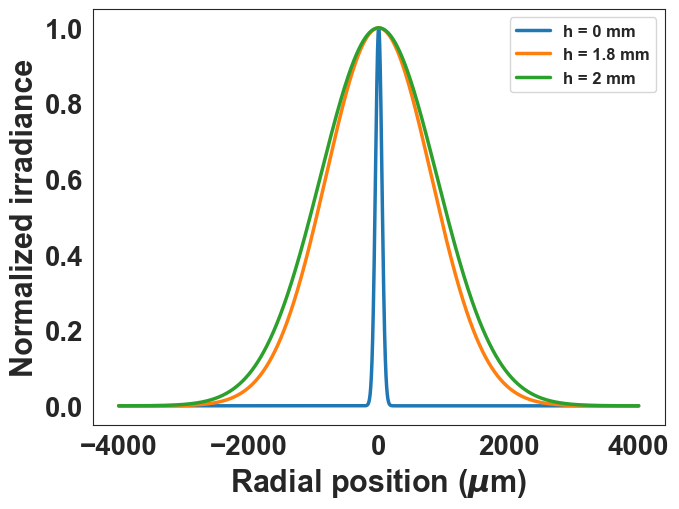

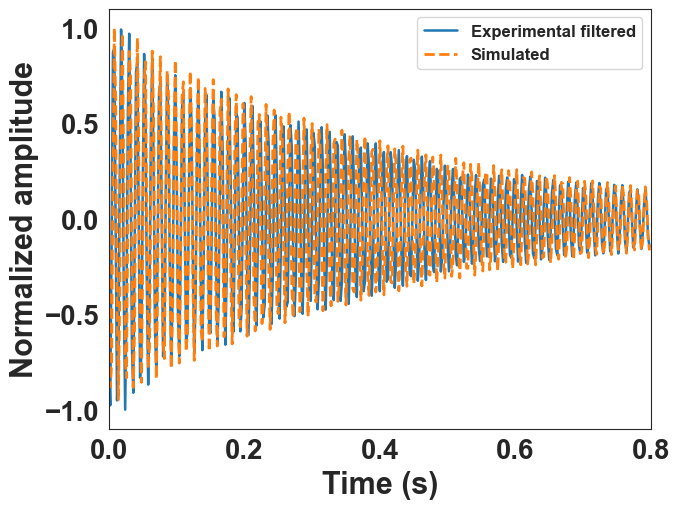

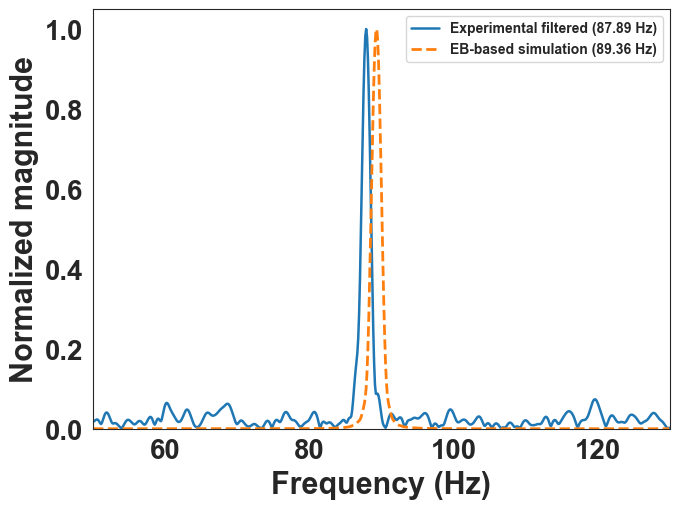

Figure 4c peak frequencies:
Experimental filtered peak: 87.891 Hz
Simulated peak: 89.355 Hz
=== Exported Figure 4 panels ===
Experimental signal used for the complete spectrum: experimental_broad_voltage
Figure 4a: optical_model_validation_outputs_v5\figure4a_gaussian_irradiance_profiles_v5.png
Figure 4b: optical_model_validation_outputs_v5\figure4b_temporal_comparison_v5.png
Figure 4c: optical_model_validation_outputs_v5\figure4c_complete_spectral_comparison_v5.png
=== Representative 80 mm signal ===
File: C:\Users\axelr\OneDrive\Escritorio\Multitask Learning for Damage Detection and Localization in Beams Using Fiber-Optic Sensors\notebooks\analysis-codes\healthy_beam_lectures\healthy_beam_8cm\ALL0016\F0016CH1.CSV
Segment: 2
Acquisition sampling frequency: 500.000 Hz
Experimental frequency, independently extracted: 88.000 Hz
Theoretical frequency: 89.318 Hz
Main-impact peak delay after detected onset: 0.0340 s
Modal-envelope peak delay after detected onset: 0.0860 s
Decay-fit R²: 0.98

In [ ]:
# ============================================================
# CELL 7 — Figure 4
# ============================================================

REPRESENTATIVE_LENGTH_MM = 80

representative_candidates = [
    row
    for row in validation_rows
    if (
        row["length_mm"]
        == REPRESENTATIVE_LENGTH_MM
    )
]

if len(
    representative_candidates
) == 0:
    raise RuntimeError(
        "No 80 mm validation signals are available."
    )

high_quality_candidates = [
    row
    for row in representative_candidates
    if (
        np.isfinite(
            row[
                "decay_fit_r2"
            ]
        )
        and row[
            "decay_fit_r2"
        ] >= FIGURE_MIN_DECAY_R2
    )
]

if len(
    high_quality_candidates
) == 0:
    high_quality_candidates = [
        row
        for row in representative_candidates
        if np.isfinite(
            row[
                "decay_fit_r2"
            ]
        )
    ]

if len(
    high_quality_candidates
) == 0:
    high_quality_candidates = (
        representative_candidates
    )
candidate_correlations = np.array(
    [
        row[
            "spectral_correlation"
        ]
        for row
        in high_quality_candidates
    ],
    dtype=float,
)

median_correlation = float(
    np.nanmedian(
        candidate_correlations
    )
)

representative_index = int(
    np.nanargmin(
        np.abs(
            candidate_correlations
            - median_correlation
        )
    )
)

representative = (
    high_quality_candidates[
        representative_index
    ]
)

temporal_time_values = representative[
    "temporal_time"
]

experimental_modal_voltage = (
    normalize_in_display_window(
        temporal_time_values,
        representative[
            "experimental_modal_voltage"
        ],
    )
)

simulated_temporal_voltage = (
    normalize_in_display_window(
        temporal_time_values,
        representative[
            "simulated_temporal_voltage"
        ],
    )
)

phase_alignment = (
    phase_align_simulation_for_display(
        experimental_modal_voltage,
        simulated_temporal_voltage,
        representative[
            "sampling_frequency_hz"
        ],
        representative[
            "experimental_frequency_hz"
        ],
    )
)

aligned_simulated_voltage = (
    phase_alignment[
        "voltage"
    ]
)

figure_mask = (
    temporal_time_values
    <= FIGURE_WINDOW_S
)

# ------------------------------------------------------------
# Panel (a): Gaussian irradiance profiles
# ------------------------------------------------------------

radial_position_um = np.linspace(
    -4000.0,
    4000.0,
    5000,
)

profile_distances_mm = [
    0.0,
    1.8,
    2.0,
]

irradiance_profiles = []

for distance_mm in (
    profile_distances_mm
):
    omega_um = (
        W0_UM
        + 2.0
        * distance_mm
        * 1000.0
        * np.tan(
            GAMMA_RAD
        )
    )

    irradiance_profiles.append(
        np.exp(
            -2.0
            * radial_position_um**2
            / omega_um**2
        )
    )


# ============================================================
# Generate Figure 4 as three independent images
# ============================================================

# ------------------------------------------------------------
# Obtain the complete experimental filtered signal
# ------------------------------------------------------------

def get_first_available_signal(
    data_mapping,
    candidate_keys,
):
    """
    Return the first valid one-dimensional signal found in
    data_mapping using the supplied candidate keys.
    """
    for key in candidate_keys:
        if (
            key in data_mapping
            and data_mapping[key] is not None
        ):
            signal = np.asarray(
                data_mapping[key],
                dtype=float,
            ).ravel()

            if signal.size > 1:
                return signal, key

    return None, None


experimental_signal_candidates = [
    "experimental_highpass_voltage",
    "experimental_detrended_highpass_voltage",
    "experimental_filtered_voltage",
    "experimental_broad_voltage",
    "experimental_full_voltage",
    "experimental_spectral_voltage",
    "spectral_experimental_voltage",
    "broad_voltage",
    "highpass_voltage",
    "high_pass_voltage",
]

experimental_full_signal, experimental_signal_key = (
    get_first_available_signal(
        representative,
        experimental_signal_candidates,
    )
)

if (
    experimental_full_signal is None
    and "selected_trace_records" in globals()
):
    matching_source_record = next(
        (
            row
            for row in selected_trace_records
            if (
                str(row.get("file_path"))
                == str(
                    representative[
                        "file_path"
                    ]
                )
                and int(
                    row.get(
                        "segment_id",
                        -1,
                    )
                )
                == int(
                    representative[
                        "segment_id"
                    ]
                )
            )
        ),
        None,
    )

    if matching_source_record is not None:
        (
            experimental_full_signal,
            experimental_signal_key,
        ) = get_first_available_signal(
            matching_source_record,
            experimental_signal_candidates,
        )


if experimental_full_signal is None:
    raise KeyError(
        "The complete detrended/high-pass experimental "
        "signal could not be found. Available representative "
        f"keys are: {sorted(representative.keys())}"
    )


# ------------------------------------------------------------
# Calculate full normalized spectra from 0 Hz to Nyquist
# ------------------------------------------------------------

def calculate_complete_normalized_spectrum(
    signal_values,
    sampling_frequency_hz,
):
    """
    Calculate a complete single-sided normalized spectrum
    using linear detrending and a Hann window.
    """
    signal_values = np.asarray(
        signal_values,
        dtype=float,
    ).ravel()

    finite_mask = np.isfinite(
        signal_values
    )

    signal_values = signal_values[
        finite_mask
    ]

    if signal_values.size < 10:
        raise ValueError(
            "Too few valid samples are available for "
            "the complete spectrum."
        )

    signal_values = detrend(
        signal_values,
        type="linear",
    )

    number_samples = len(
        signal_values
    )

    n_fft = max(
        4096,
        2 ** int(
            np.ceil(
                np.log2(
                    number_samples
                )
            )
        ),
    )

    window = np.hanning(
        number_samples
    )

    spectrum = np.fft.rfft(
        signal_values * window,
        n=n_fft,
    )

    magnitude = np.abs(
        spectrum
    )

    frequencies_hz = np.fft.rfftfreq(
        n_fft,
        d=(
            1.0
            / sampling_frequency_hz
        ),
    )

    maximum_magnitude = float(
        np.max(
            magnitude
        )
    )

    if maximum_magnitude > 0:
        magnitude = (
            magnitude
            / maximum_magnitude
        )

    return frequencies_hz, magnitude


sampling_frequency_hz = float(
    representative[
        "sampling_frequency_hz"
    ]
)

experimental_full_frequency_hz, experimental_full_spectrum = (
    calculate_complete_normalized_spectrum(
        experimental_full_signal,
        sampling_frequency_hz,
    )
)

simulated_full_frequency_hz, simulated_full_spectrum = (
    calculate_complete_normalized_spectrum(
        representative[
            "simulated_temporal_voltage"
        ],
        sampling_frequency_hz,
    )
)

maximum_display_frequency_hz = min(
    150.0,
    sampling_frequency_hz / 2.0,
)


# ============================================================
# Figure 4a — Gaussian irradiance profiles
# ============================================================

fig_4a, ax_4a = plt.subplots(
    figsize=(7.2, 5.5),
)

for distance_mm, profile in zip(
    profile_distances_mm,
    irradiance_profiles,
):
    ax_4a.plot(
        radial_position_um,
        profile,
        linewidth=2.5,
        label=(
            f"h = {distance_mm:g} mm"
        ),
    )

ax_4a.set_xlabel(
    r"Radial position ($\mu$m)"
)

ax_4a.set_ylabel(
    "Normalized irradiance"
)

ax_4a.legend()

fig_4a.tight_layout()

figure_4a_path = (
    VALIDATION_OUTPUT_DIR
    / "figure4a_gaussian_irradiance_profiles_v5.png"
)

fig_4a.savefig(
    figure_4a_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# Figure 4b — Temporal comparison
# ============================================================

fig_4b, ax_4b = plt.subplots(
    figsize=(7.2, 5.5),
)

ax_4b.plot(
    temporal_time_values[
        figure_mask
    ],
    experimental_modal_voltage[
        figure_mask
    ],
    linewidth=1.8,
    label="Experimental filtered",
)

ax_4b.plot(
    temporal_time_values[
        figure_mask
    ],
    aligned_simulated_voltage[
        figure_mask
    ],
    linewidth=2.0,
    linestyle="--",
    label="Simulated",
)

ax_4b.set_xlabel(
    "Time (s)"
)

ax_4b.set_ylabel(
    "Normalized amplitude"
)

ax_4b.set_xlim(
    0.0,
    FIGURE_WINDOW_S,
)

ax_4b.legend()

fig_4b.tight_layout()

figure_4b_path = (
    VALIDATION_OUTPUT_DIR
    / "figure4b_temporal_comparison_v5.png"
)

fig_4b.savefig(
    figure_4b_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# Figure 4c — Complete spectral comparison
# ============================================================

fig_4c, ax_4c = plt.subplots(
    figsize=(7.2, 5.5),
)

# Display range for the spectrum
minimum_display_frequency_hz = 50.0
maximum_display_frequency_hz = min(
    130.0,
    sampling_frequency_hz / 2.0,
)

experimental_frequency_mask = (
    (experimental_full_frequency_hz >= minimum_display_frequency_hz)
    & (experimental_full_frequency_hz <= maximum_display_frequency_hz)
)

simulated_frequency_mask = (
    (simulated_full_frequency_hz >= minimum_display_frequency_hz)
    & (simulated_full_frequency_hz <= maximum_display_frequency_hz)
)

# ------------------------------------------------------------
# Extract displayed spectral portions
# ------------------------------------------------------------
exp_freq_display = experimental_full_frequency_hz[
    experimental_frequency_mask
]
exp_mag_display = experimental_full_spectrum[
    experimental_frequency_mask
]

sim_freq_display = simulated_full_frequency_hz[
    simulated_frequency_mask
]
sim_mag_display = simulated_full_spectrum[
    simulated_frequency_mask
]

# ------------------------------------------------------------
# Peak frequencies for legend
# ------------------------------------------------------------
exp_peak_idx = int(np.argmax(exp_mag_display))
sim_peak_idx = int(np.argmax(sim_mag_display))

exp_peak_hz = float(exp_freq_display[exp_peak_idx])
sim_peak_hz = float(sim_freq_display[sim_peak_idx])

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
ax_4c.plot(
    exp_freq_display,
    exp_mag_display,
    linewidth=1.8,
    label=f"Experimental filtered ({exp_peak_hz:.2f} Hz)",
)

ax_4c.plot(
    sim_freq_display,
    sim_mag_display,
    linewidth=2.0,
    linestyle="--",
    label=f"EB-based simulation ({sim_peak_hz:.2f} Hz)",
)

ax_4c.set_xlabel(
    "Frequency (Hz)"
)

ax_4c.set_ylabel(
    "Normalized magnitude"
)

ax_4c.set_xlim(
    minimum_display_frequency_hz,
    maximum_display_frequency_hz,
)

ax_4c.set_ylim(
    0.0,
    1.05,
)

ax_4c.legend(
    fontsize=10,
)

fig_4c.tight_layout()

figure_4c_path = (
    VALIDATION_OUTPUT_DIR
    / "figure4c_complete_spectral_comparison_v5.png"
)

fig_4c.savefig(
    figure_4c_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure 4c peak frequencies:"
)
print(
    f"Experimental filtered peak: {exp_peak_hz:.3f} Hz"
)
print(
    f"Simulated peak: {sim_peak_hz:.3f} Hz"
)


print(
    "=== Exported Figure 4 panels ==="
)

print(
    "Experimental signal used for the complete spectrum:",
    experimental_signal_key,
)

print(
    "Figure 4a:",
    figure_4a_path,
)

print(
    "Figure 4b:",
    figure_4b_path,
)

print(
    "Figure 4c:",
    figure_4c_path,
)

print(
    "=== Representative 80 mm signal ==="
)
print(
    "File:",
    representative[
        "file_path"
    ],
)
print(
    "Segment:",
    representative[
        "segment_id"
    ],
)
print(
    "Acquisition sampling frequency:",
    f"{representative['sampling_frequency_hz']:.3f} Hz",
)
print(
    "Experimental frequency, independently extracted:",
    f"{representative['experimental_frequency_hz']:.3f} Hz",
)
print(
    "Theoretical frequency:",
    f"{representative['theoretical_frequency_hz']:.3f} Hz",
)
print(
    "Main-impact peak delay after detected onset:",
    f"{representative['excitation_peak_delay_s']:.4f} s",
)
print(
    "Modal-envelope peak delay after detected onset:",
    f"{representative['modal_peak_delay_s']:.4f} s",
)
print(
    "Decay-fit R²:",
    f"{representative['decay_fit_r2']:.4f}",
)
print(
    "Display-only phase lag:",
    f"{phase_alignment['lag_samples']} samples "
    f"({phase_alignment['lag_seconds']:.6f} s)",
)
print(
    "Temporal modal band:",
    f"{representative['modal_low_hz']:.2f}–"
    f"{representative['modal_high_hz']:.2f} Hz",
)
print(
    "Independent spectral interval:",
    f"{representative['spectral_low_hz']:.2f}–"
    f"{representative['spectral_high_hz']:.2f} Hz",
)
print(
    "Local spectral correlation:",
    f"{representative['spectral_correlation']:.4f}",
)
print(
    "Local spectral NRMSE:",
    f"{representative['spectral_nrmse']:.4f}",
)
print(
    "Figure 4a:",
    figure_4a_path,
)

print(
    "Figure 4b:",
    figure_4b_path,
)

print(
    "Figure 4c:",
    figure_4c_path,
)